# Information Theory Based Parameter Correlation

This notebook is used as a research internship project that applies information theory to machine learning parameter correlation analysis.

*Author: Lawrence Zhang, University of Glasgow*

*Supervisor: Ankush Aggarwal, University of Glasgow*

## Imports




#### Dependencies

Calculation: numpy, fraction, NPEET (entropy estimator tool, contained in the repo), sklearn PCA (technically this can be done with only numpy but here scikit-learn is used for convenience), scipy (for optimisation)

Data visualisation: matplotlib

In [1]:
#set-ups
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
from npeet import entropy_estimators as ee
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize
from fractions import Fraction
from itertools import combinations

In [2]:
#test use

x = np.array([[1.3], [3.7], [5.1], [2.4], [3.4]])
y = np.array([[1.5], [3.32], [5.3], [2.3], [3.3]])

print(ee.mi(x,y))

X = np.column_stack([x, y])
pca = PCA()
pca.fit(X)

print(pca.components_)
print(pca.explained_variance_)
print(pca.explained_variance_ratio_)
print("ready to run")

0.16831442143704642
[[ 0.70775233  0.70646065]
 [-0.70646065  0.70775233]]
[4.03694334 0.02973666]
[0.99268773 0.00731227]
ready to run


### Background Notes

#### PCA: Principle Component Analysis

Analysis tool used to determine principle component, in other words identify the directions along which the data varies the most.

PC1 is defined as the direction of max variance which contains most information. PC2 is orthogonal to PC1, capturing remaining variance.

##### Theoretical

Given a centered data matrix

$$
X \in \mathbb{R}^{n \times p}
$$

the covariance matrix is

$$
C = \frac{1}{n-1}X^TX
$$

PCA computes the eigenvalue decomposition (very similar to SVD)

$$
C = V\Lambda V^T
$$

where:

- $V$: eigenvectors (principal directions)
- $\Lambda$: eigenvalues (variance explained by each direction)

The principal components are ordered according to decreasing eigenvalues.

##### Application Use

*For use, refer to https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html for more details*


#### EE: Entropy Estimator

##### Theoretical

###### MI

Given two random variables \(X\) and \(Y\), with joint distribution

$$
p(x,y)
$$

and marginal distributions

$$
p(x), \quad p(y),
$$

the mutual information is defined as

$$
I(X;Y)
=
\int\int
p(x,y)
\log
\frac{p(x,y)}
     {p(x)p(y)}
\,dx\,dy
$$

Equivalent entropy-based formulations are

$$
I(X;Y)
=
H(X)-H(X|Y)
$$

$$
I(X;Y)
=
H(Y)-H(Y|X)
$$

$$
I(X;Y)
=
H(X)+H(Y)-H(X,Y)
$$

where:

- \(H(X)\): entropy of \(X\)
- \(H(Y)\): entropy of \(Y\)
- \(H(X,Y)\): joint entropy
- \(H(X|Y)\): conditional entropy

Interpretation:

- \(I(X;Y)=0\): \(X\) and \(Y\) are independent
- Larger \(I(X;Y)\): stronger dependence
- Captures both linear and nonlinear relationships

###### CMI

Given three random variables \(X\), \(Y\), and \(Z\), the conditional mutual information is defined as

$$
I(X;Y|Z)
=
\iiint
p(x,y,z)
\log
\frac{p(x,y|z)}
     {p(x|z)p(y|z)}
\,dx\,dy\,dz
$$

Equivalent entropy formulation:

$$
I(X;Y|Z)
=
H(X|Z)-H(X|Y,Z)
$$

or

$$
I(X;Y|Z)
=
H(X,Z)+H(Y,Z)-H(Z)-H(X,Y,Z)
$$

where:

- \(H(X|Z)\): conditional entropy of \(X\) given \(Z\)
- \(H(X|Y,Z)\): remaining uncertainty in \(X\) after observing \(Y\) and \(Z\)

Interpretation:

- \(I(X;Y|Z)=0\): \(X\) and \(Y\) are conditionally independent given \(Z\)
- Large values indicate dependence remains even after conditioning on \(Z\)


##### Application Use

*The NPEET library uses a KNN algorithm for calculation, so the result might be < 0*

*For use, refer to https://github.com/gregversteeg/NPEET for more details*

## Linear Combination (without noise)

In this section, some linear combinations of parameters will be tested through both entropy test and PCA, and comparing their results. 

It is suggested to check with manually constructed relationships first. Some helper functions are defined as below:


In [3]:
#helper functions
def show_2d(x,y): #visualisation
    plt.figure(figsize=(3, 3))
    plt.scatter(x, y)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis('equal') 
    plt.show()
    
def show_3d(a,b,y): #visualisation
    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(a, b, y, s=5)
    ax.set_xlabel('a')
    ax.set_ylabel('b')
    ax.set_zlabel('y')
    ax.view_init(elev=30, azim=45)

    plt.show()
    
def pca_2d(a,b,y): #data
    print("PCA:")
    pca.fit(np.column_stack([y, a]))
    print(pca.components_)
    print("Variance ratio (y,a): " + str(pca.explained_variance_ratio_))
    pca.fit(np.column_stack([y, b]))
    print(pca.components_)
    print("Variance ratio (y,b): " + str(pca.explained_variance_ratio_))
    pca.fit(np.column_stack([a, b, y]))
    print(pca.components_)
    print("Variance ratio (a,b,y): " + str(pca.explained_variance_ratio_))
    print("--------------------------")
    
def ee_2d(a,b,y): #data
    print("EE:")
    print("I(y;a): " + str(ee.mi(y,a)))
    print("I(y;b): " + str(ee.mi(y,b)))
    print("I(a;y|b): " + str(ee.cmi(a,y,b)))
    print("I(b;y|a): " + str(ee.cmi(b,y,a)))
    print("--------------------------")
    

### 2D experiment

Run corresponding cells (or create new cells) to get different parameter pairs and combinations:

In [4]:
#run this first and get randomly generated a & b
a = np.random.randn(1000)
b = np.random.randn(1000)

In [5]:
y = a

In [6]:
y = a + b

In [151]:
y = 2*a + 0.5*b

In [19]:
y = 3*a + 0.0001*b

In [85]:
y = 3*a + 0.01*b

EE:
I(y;a): 0.5248374588220969
I(y;b): 0.5131364204700006
I(a;y|b): 3.4340047711474453
I(b;y|a): 3.4224639985731993
--------------------------
PCA:
[[ 0.840665   0.5415555]
 [-0.5415555  0.840665 ]]
Variance ratio (y,a): [0.86845829 0.13154171]
[[ 0.85278566  0.52226106]
 [-0.52226106  0.85278566]]
Variance ratio (y,b): [0.86246008 0.13753992]
[[ 0.42628517  0.38994175  0.81622692]
 [-0.69638181  0.71736469  0.02098288]
 [ 0.57735027  0.57735027 -0.57735027]]
Variance ratio (a,b,y): [7.36573640e-01 2.63426360e-01 8.88470918e-17]
--------------------------


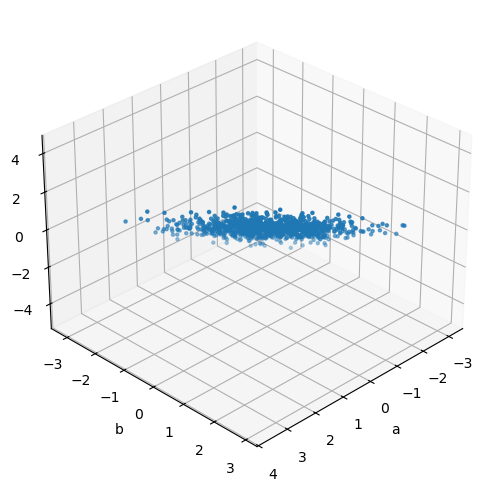

In [7]:
#results
ee_2d(a,b,y)
pca_2d(a,b,y)
show_3d(a,b,y)

#### Interpretation

__Please make sure you run the *results* cell to update PCA results__

PCA extracts orthogonal directions that explain the variance structure of the data. The first term in pca_components is the direction that maximises the variance (change). If the associated variance is close to zero, it may indicate an approximate linear constraint among the variables.

The interpretation approach is to check the explained variance ratio of the last principal component. When the value is negligible (the threshold is set to be 1e-8), it suggests that the corresponding eigenvector may represent an approximate linear relationship among the variables.. Fraction module is used to approximate the ratio. Note that although the interpreter works well on manually constructed relationships, it is not tested against actual experiment data.

The interpreter function below takes 3 parameters, pca_components, pca_ratio and param_names. The last argument is optional.

The exact format of the restored relationship (which term sits on LHS) depends on the argument order passed to pca calculation function.

In [8]:
def pca_interpretation(components, ratio, param_names=None):
    print("=====PCA=====")
    if len(ratio) != len(components):
        print("Invalid inputs")
        return
    if ratio[-1] >= 1e-6: #when the last component ratio is negletable, it means this direction fits orginal correlation well
        print("No significant linear relationship is found in this PCA analysis.")
        return
    v = np.array(components[-1])
    v = v / np.min(np.abs(v[np.abs(v) > 1e-8])) #threshold
    coeffs = [Fraction(x).limit_denominator(10) for x in v]
    
    print("Detected ratio:")
    print(coeffs)
    
    if param_names is None:
        param_names = [chr(ord('a') + i) for i in range(len(coeffs))] #ascii
        
    lhs_coeff = -coeffs[-1]
    lhs_var = param_names[-1]

    rhs_terms = []

    for c, name in zip(coeffs[:-1], param_names[:-1]):

        if c == 0:
            continue

        sign = "+" if c > 0 else "-"

        rhs_terms.append(
            (sign, abs(c), name)
        )

    equation = f"{lhs_coeff}{lhs_var} = "

    first = True

    for sign, c, name in rhs_terms:

        if first:
            if sign == "-":
                equation += "-"
            equation += f"{c}{name}"
            first = False
        else:
            equation += f" {sign} {c}{name}"

    print("\nApproximate relation:")
    print(equation)

EE result interpretation:

Optimisation is used here for searching over fitting coefficients. Scipy.optimize library is used, refer to: https://docs.scipy.org/doc/scipy/tutorial/optimize.html for more details.

In [24]:
def ee_interpretation_2d(a, b, y, param_names=None): #uses grid search, only available in 2d
    print("=====EE=====")
    thetas = np.linspace(0, 2*np.pi, 7200, endpoint=False) #higher resolution gives higher precision but gets very slow
    if param_names is None:
        param_names = [chr(ord('a') + i) for i in range(2)] #ascii
    
    mi_scores = []
    for theta in thetas:
        alpha = np.cos(theta)
        beta = np.sin(theta)
        mi_scores.append(ee_objective(alpha,beta,a,b,y))

    mi_scores = np.array(mi_scores)
    best_theta = thetas[np.argmax(mi_scores)]
    
    alpha = np.cos(best_theta)
    beta = np.sin(best_theta)

    print(f"Maximum MI : {mi_scores[np.argmax(mi_scores)]}")

    v = np.array([alpha, beta])
    v = v / np.min(np.abs(v[np.abs(v) > 1e-8]))
    coeffs = [Fraction(x).limit_denominator(10) for x in v]

    if coeffs[0] < 0:
        coeffs = [-c for c in coeffs]

    print("\nRecovered coefficients:")
    print(coeffs)

    print("\nApproximate relationship:")
    print(f"y ≈ {coeffs[0]}{param_names[0]} + {coeffs[1]}{param_names[1]}")
    
    #not efficient but probably will not further improve this function
        
def ee_objective(coeffs, X, y):
    coeffs = np.asarray(coeffs, dtype=float)
    coeffs /= np.linalg.norm(coeffs)
    u = X @ coeffs
    return ee.mi(y, u)
    
def ee_interpretation(a,b,y, step_size=0.2, max_iteration=100, param_names=None, tolerance=1e-6): 
    #optimisation: try against (a+m,b),(a-m,b),(a,b+m),(a,b-m)
    #has bugs. might fix them later
    print("=====EE=====")
    
    if param_names is None:
        param_names = [chr(ord('a') + i) for i in range(2)] #ascii
        
    alpha = 1 #initialisation
    beta = 0
    X = np.column_stack((a, b))
    current_score = ee_objective([alpha, beta], X, y)
    
    #main iteration loop
    for i in range(max_iteration):
        neighbours = [
            ( step_size, 0),
            (-step_size, 0),
            (0, step_size),
            (0,-step_size),
        ]
        best_alpha = alpha
        best_beta = beta
        best_score = current_score
        improved = False
        
        for da,db in neighbours: #4 directions
            new_alpha = alpha + da
            new_beta = beta + db
            norm = np.sqrt(new_alpha**2 + new_beta**2)

            if norm < 1e-12:
                continue

            new_alpha /= norm
            new_beta /= norm

            score = ee_objective([new_alpha, new_beta], X, y)
            
            if score > best_score:
                best_score = score
                best_alpha = new_alpha
                best_beta = new_beta
                improved = True

            if improved:
                alpha = best_alpha
                beta = best_beta
                current_score = best_score

            else:
                step_size *= 0.5
            
            if step_size < tolerance:
                break
            
        norm = np.sqrt(alpha**2 + beta**2)
        alpha /= norm
        beta /= norm

    #output
    if alpha < 0:
        alpha *= -1
        beta *= -1
    coeff = np.array([alpha, beta])
    coeff[np.abs(coeff) < 1e-6] = 0

    if np.any(coeff != 0):
        coeff /= np.min(np.abs(coeff[np.abs(coeff) > 0]))

    coeff = [Fraction(x).limit_denominator(10) for x in coeff]

    print(f"Iterations : {max_iteration}")
    print(f"Maximum MI : {current_score:.6f}")

    print("\nRecovered direction:")
    print(f"{alpha:.6f}{param_names[0]} + {beta:.6f}{param_names[1]}")

    print("\nApproximate coefficients:")
    print(coeff)

    print("\nApproximate relationship:")
    print(f"y ∝ {coeff[0]}{param_names[0]} + {coeff[1]}{param_names[1]}")
    #not normalising by y
    #limited by step size & algorithm. use scipy instead

def scipy_objective(coeffs, X, y):
    return -ee_objective(coeffs, X, y)
    
def ee_interpretation_scipy(X,y,param_names=None,initial_guess=(1, 0),method="Powell"):
    print("=====EE (SciPy)=====")
    
    X = np.asarray(X)
    n = X.shape[1]

    if param_names is None:
        if n <= 26:
            param_names = [chr(ord('a') + i) for i in range(n)]
        else:
            param_names = [f"x{i}" for i in range(n)]

    if initial_guess is None:
        initial_guess = np.ones(n)

    result = minimize(scipy_objective, x0=np.asarray(initial_guess, dtype=float), args=(X, y), method=method)

    #result display
    coeff = result.x.astype(float)
    coeff /= np.linalg.norm(coeff)
    
    z = X @ coeff
    gamma = np.cov(z, y, bias=True)[0,1] / np.var(z)
    coeff = gamma * coeff
    
    idx = np.argmax(np.abs(coeff))
    if coeff[idx] < 0:
        coeff *= -1

    print(f"Success : {result.success}")
    print(f"Iterations : {result.nit}")
    print(f"Function evaluations : {result.nfev}")
    print(f"Maximum MI : {-result.fun:.6f}")

    print("\nRecovered direction:")
    terms = []
    for c, name in zip(coeff, param_names):
        terms.append(f"{c:.6f}{name}")

    print(" + ".join(terms))

    coeff2 = coeff.copy()

    coeff2[np.abs(coeff2) < 1e-6] = 0

    ratios = [
        Fraction(x).limit_denominator(20)
        for x in coeff2
    ]

    print("\nApproximate coefficients:")
    print(ratios)

    relation = " + ".join(
        f"{r}{name}"
        for r, name in zip(ratios, param_names)
    )

    print("\nApproximate relationship:")
    print(f"y ∝ {relation}")

In [26]:
#example use
pca_interpretation(pca.components_, pca.explained_variance_ratio_)
#ee_interpretation(a,b,y,0.8,300) #output depends on step size greatly
ee_interpretation_scipy(np.column_stack((a, b)),y)
#still suffers when magnitude differs by too much

=====PCA=====
No significant linear relationship is found in this PCA analysis.
=====EE (SciPy)=====
Success : True
Iterations : 2
Function evaluations : 84
Maximum MI : 5.607215

Recovered direction:
7.004272a + 2.988589b

Approximate coefficients:
[Fraction(7, 1), Fraction(3, 1)]

Approximate relationship:
y ∝ 7a + 3b


In [11]:
#EE interpretation does not work well when the coefficients' magnitude differs by too much.

### 3D & Higher Dimensions

Add new cells to get more combinations.

In [12]:
#helper functions
def ee_3d(a,b,c,y):
    print("EE:")
    print("I(y;a): " + str(ee.mi(y,a)))
    print("I(y;b): " + str(ee.mi(y,b)))
    print("I(y;c): " + str(ee.mi(y,b)))
    print("I(a;y|b): " + str(ee.cmi(a,y,b)))
    print("I(b;y|a): " + str(ee.cmi(b,y,a)))
    print("I(c;y|b): " + str(ee.cmi(c,y,b)))
    print("I(c;y|a): " + str(ee.cmi(c,y,a)))
    print("I(a;y|c): " + str(ee.cmi(a,y,c)))
    print("I(b;y|c): " + str(ee.cmi(b,y,c)))
    print("--------------------------")
    
def pca_3d(a,b,c,y): #pca result becomes hard to interpret so normalisation is used here
    print("PCA:")
    pca.fit(np.column_stack([a, b, c, y]))
    print(pca.components_)
    print("Variance ratio: " + str(pca.explained_variance_ratio_))
    print("--------------------------")

In [13]:
c = np.random.randn(1000)

y = a + 13*b - 4*c

In [14]:
y = -3*b + 2*c

In [15]:
#results 3D
ee_3d(a,b,c,y)
pca_3d(a,b,c,y)

EE:
I(y;a): 0.0038541387386378666
I(y;b): 0.9007600662553907
I(y;c): 0.9007600662553907
I(a;y|b): 0.029605174366371705
I(b;y|a): 0.8792332594551924
I(c;y|b): 2.6190654331649323
I(c;y|a): 0.2867158699281913
I(a;y|c): 0.052978615485489565
I(b;y|c): 3.42942252993572
--------------------------
PCA:
[[ 1.38377263e-02 -2.25477849e-01  1.43541490e-01  9.63516527e-01]
 [ 9.97862138e-01  3.84667253e-02  5.12201931e-02 -1.29597897e-02]
 [-6.38722993e-02  5.52107696e-01  8.31299012e-01  6.27493586e-03]
 [-5.78602170e-17  8.01783726e-01 -5.34522484e-01  2.67261242e-01]]
Variance ratio: [0.87136086 0.06672468 0.06191446 0.        ]
--------------------------


In [16]:
#interpretation
pca_interpretation(pca.components_, pca.explained_variance_ratio_)

Detected ratio:
[Fraction(0, 1), Fraction(3, 1), Fraction(-2, 1), Fraction(1, 1)]

Approximate relation:
-1d = 3b - 2c


In [16]:
#helper functions to get randomly generated linear combinations
def generate_linear_problem(
        n,
        sample_size=1000,
        coeff_range=(-20,20),
        seed=None):
    if seed is not None:
        np.random.seed(seed)

    X = np.random.randn(sample_size, n)
    coeffs = np.random.randint(
        coeff_range[0],
        coeff_range[1] + 1,
        size=n
    )
    while np.all(coeffs == 0):
        coeffs = np.random.randint(
            coeff_range[0],
            coeff_range[1] + 1,
            size=n
        )
    y = X @ coeffs
    return X, y, coeffs

def pca_nd(X, y):
    data = np.column_stack([X, y])
    pca.fit(data)
    print("PCA:")
    print(pca.components_)
    print("Variance ratio:")
    print(pca.explained_variance_ratio_)

def ee_nd(X, y):
    n = X.shape[1]
    print("EE:")

    for i in range(n):
        print(
            f"I(y;x{i+1}): "
            + str(ee.mi(y, X[:, i]))
        )

    for target in range(n):

        others = [j for j in range(n) if j != target]

        for cond in others:

            print(
                f"I(x{target+1};y|x{cond+1}): "
                + str(
                    ee.cmi(
                        X[:, target],
                        y,
                        X[:, cond]
                    )
                )
            )
    print("--------------------------")

In [17]:
X,y,c = generate_linear_problem(5) #an example randomly-generated linear combination
print(c) #coefficients
pca_nd(X,y)
ee_nd(X,y)

[-20  15  17   5   8]
PCA:
[[-1.88386069e-02  1.40818720e-02  1.84873694e-02  3.56332997e-03
   9.92433038e-03  9.99496791e-01]
 [ 4.95550455e-02  2.18223279e-01 -5.69031320e-01  5.08942144e-01
   6.05890949e-01  5.54136040e-04]
 [ 6.49124813e-01  7.21604520e-01  1.91199848e-01  1.43396527e-02
  -1.45467801e-01 -7.51817315e-05]
 [ 3.22472658e-01 -2.26888587e-01  3.54505306e-01 -4.16753048e-01
   7.38353610e-01 -3.12812946e-03]
 [ 2.70982272e-01 -3.94823001e-01  4.75164787e-01  7.36326062e-01
  -5.22083437e-02 -2.25524791e-04]
 [ 6.31194403e-01 -4.73395802e-01 -5.36515243e-01 -1.57798601e-01
  -2.52477761e-01  3.15597202e-02]]
Variance ratio:
[9.95959208e-01 1.11048228e-03 1.03294575e-03 9.98302792e-04
 8.99061283e-04 1.50811389e-16]
EE:
I(y;x1): 0.3342065505785269
I(y;x2): 0.15580494098091904
I(y;x3): 0.2608064028259267
I(y;x4): -0.0407723188860091
I(y;x5): 0.14139714205022616
I(x1;y|x2): 0.4218231455206653
I(x1;y|x3): 0.4227571553992096
I(x1;y|x4): 0.27442447120508284
I(x1;y|x5): 0.30

In [141]:
pca_interpretation(pca.components_, pca.explained_variance_ratio_)

Detected ratio:
[Fraction(-11, 1), Fraction(-13, 1), Fraction(-12, 1), Fraction(-17, 1), Fraction(18, 1), Fraction(1, 1)]

Approximate relation:
-1f = -11a - 13b - 12c - 17d + 18e


## Non-Linear Combination (Manually generated)

Some non-linear combinations will be tested.



In [18]:
y = a**2

EE:
I(y;a): 6.199268406291354
I(y;b): -0.020674977862907777
I(a;y|b): 2.574398562850139
I(b;y|a): -0.068158494495527
--------------------------
PCA:
[[ 0.99979772  0.02011266]
 [-0.02011266  0.99979772]]
Variance ratio (y,a): [0.66917954 0.33082046]
[[ 0.99928285 -0.03786543]
 [ 0.03786543  0.99928285]]
Variance ratio (y,b): [0.6816586 0.3183414]
[[ 0.02138391 -0.03853439  0.99902844]
 [ 0.90111186 -0.43209337 -0.03595469]
 [ 0.43305906  0.90100523  0.02548395]]
Variance ratio (a,b,y): [0.5099825  0.25604799 0.23396951]
--------------------------


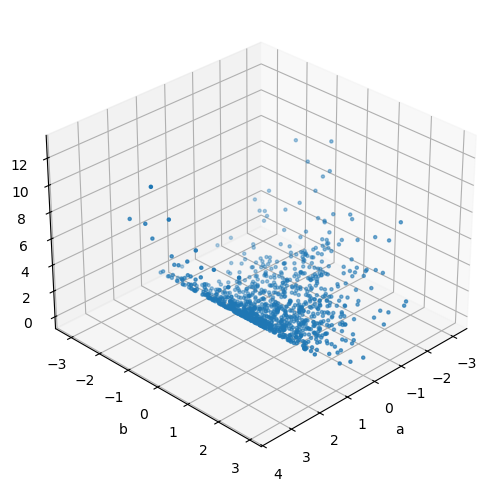

In [19]:
#results
ee_2d(a,b,y)
pca_2d(a,b,y)
show_3d(a,b,y)

#### Interpretation

PCA could only recognise linear combinations, therefore, pca_interpretation does not work as linear examples above (no negligible value in explained_variance_ratio).

However, EE would still work and recognises there's a pattern between y and a.

In [119]:
pca_interpretation(pca.components_, pca.explained_variance_ratio_)

=====PCA=====
No significant linear relationship is found in this PCA analysis.


## Linear Combination (with noise)

As shown above, pure linear combinations can be easily recognised by PCA method, with a very high accuracy.

In this section some noise will be introduced to data and see the comparison between two methods.

Noise_level is defined in the cell below, and modifications could be made to change the noise level. Note that noise level here is __not percentage__.

In [20]:
#noise set-up
noise_level = [0, 0.002, 0.05, 0.1, 0.2, 0.5, 1] #values

def add_noise(y):
    ys = []

    for sigma in noise_level:
        noise = np.random.normal(
            0,
            sigma,
            len(y)
        )
        ys.append(y + noise)

    return ys

In [21]:
y = 2*a + b

In [22]:
y = 7*a + 3*b

In [27]:
#results
ys = add_noise(y)

for sigma, y_noisy in zip(noise_level, ys):
    print(f"Noise level = {sigma}")
    ee_2d(a, b, y_noisy)
    pca_2d(a, b, y_noisy)
    pca_interpretation(pca.components_, pca.explained_variance_ratio_)
    print("===========================")

Noise level = 0
EE:
I(y;a): 1.4097151961866823
I(y;b): 0.1268549180523354
I(a;y|b): 2.8527715653701984
I(b;y|a): 1.4612036917918654
--------------------------
PCA:
[[ 0.99247799  0.12242316]
 [-0.12242316  0.99247799]]
Variance ratio (y,a): [0.99737934 0.00262066]
[[ 0.99889859  0.04692132]
 [-0.04692132  0.99889859]]
Variance ratio (y,b): [0.98553328 0.01446672]
[[ 0.12201315  0.04579315  0.99147152]
 [-0.39319755  0.91943494  0.00592196]
 [ 0.91132238  0.39056673 -0.13018891]]
Variance ratio (a,b,y): [9.83135413e-01 1.68645867e-02 1.80260554e-16]
--------------------------
=====PCA=====
Detected ratio:
[Fraction(7, 1), Fraction(3, 1), Fraction(-1, 1)]

Approximate relation:
1c = 7a + 3b
Noise level = 0.002
EE:
I(y;a): 1.4087245243291477
I(y;b): 0.12695976037884465
I(a;y|b): 2.852768049506869
I(b;y|a): 1.4634586797419322
--------------------------
PCA:
[[ 0.99247807  0.12242252]
 [-0.12242252  0.99247807]]
Variance ratio (y,a): [0.99737921 0.00262079]
[[ 0.99889853  0.0469226 ]
 [-0.0

In [28]:
for sigma, y_noisy in zip(noise_level, ys):
    print(f"Noise level = {sigma}")
    ee_interpretation_scipy(np.column_stack((a, b)),y_noisy)
    print("===========================")
    
# does not work well when y = 2*a only, where a will get a very huge coefficient

Noise level = 0
=====EE (SciPy)=====
Success : True
Iterations : 2
Function evaluations : 84
Maximum MI : 5.607215

Recovered direction:
7.004272a + 2.988589b

Approximate coefficients:
[Fraction(7, 1), Fraction(3, 1)]

Approximate relationship:
y ∝ 7a + 3b
Noise level = 0.002
=====EE (SciPy)=====
Success : True
Iterations : 2
Function evaluations : 112
Maximum MI : 5.612206

Recovered direction:
7.003086a + 2.991786b

Approximate coefficients:
[Fraction(7, 1), Fraction(3, 1)]

Approximate relationship:
y ∝ 7a + 3b
Noise level = 0.05
=====EE (SciPy)=====
Success : True
Iterations : 2
Function evaluations : 105
Maximum MI : 5.541271

Recovered direction:
6.998301a + 3.004211b

Approximate coefficients:
[Fraction(7, 1), Fraction(3, 1)]

Approximate relationship:
y ∝ 7a + 3b
Noise level = 0.1
=====EE (SciPy)=====
Success : True
Iterations : 2
Function evaluations : 82
Maximum MI : 5.349751

Recovered direction:
7.001804a + 2.993975b

Approximate coefficients:
[Fraction(7, 1), Fraction(3, 

#### Interpretation

As noise level increases, PCA's ability to recognise linear combinations decreases very fast. It could barely handle data with noises.

In contrast, entropy estimator still recognises coefficients even with a strong noise. 

### Exponential Combinations

In this section some exponential combinations will be tested where these problems could be turned into linear combinations of log arithmetics.

In [158]:
a = np.random.uniform(1, 10, 1000)
b = np.random.uniform(1, 10, 1000)
y = 5*a*b**0.5 + a

In [29]:
#does not work when a or b contains non-positive numbers. In practice all the data are positive I assume?
log_a = np.log(a)
log_b = np.log(b)
log_y = np.log(y)
X = np.column_stack([log_a, log_b])
ee_interpretation_scipy(X,log_y)

C:\Users\Law\AppData\Local\Temp\ipykernel_84248\167187236.py:2: RuntimeWarning: invalid value encountered in log
  log_a = np.log(a)
C:\Users\Law\AppData\Local\Temp\ipykernel_84248\167187236.py:3: RuntimeWarning: invalid value encountered in log
  log_b = np.log(b)
C:\Users\Law\AppData\Local\Temp\ipykernel_84248\167187236.py:4: RuntimeWarning: invalid value encountered in log
  log_y = np.log(y)


=====EE (SciPy)=====


ValueError: Input contains NaN.

In [ ]:
#test nonlinear relationship
#

## Real Data Estimation
The overall idea is: can we identify parameters with only limited observations? 

In this section, some virtual patient data (Windkessel model) will be used to test with the method. Currently it is only considering v_rv and v_lv two outputs, and only concerning about their maximum and minumum (so in general, 4 y values to be optimised). The input parameters are: ['C_s', 'Za_s','R_s','C_p','Za_p','R_p']

* There's two datasets, one with full 520,000 virtual patient data (not filtered, still keeping non-physiological wave) and a filtered one. With current results, the full set produces a relatively more complex *u*, and the power feature selection differs slightly with the filtered set. Thus for convenience, most analyse were based on the filtered set and its results.

* With some prior tests, 5% random sampling of the whole dataset is sufficient for discovering the leading power features (as in previous runs, it produces identical results with 25% sampling). Considering the filtered set is smaller in size, 30% of all data is used for power feature discovery.

Be sure to run scipy_objective in the above section.

### Interpretation

The learned model maps the original Windkessel parameters to a
one-dimensional representation:

$$
X
\rightarrow
\Theta(X)
\rightarrow
u
$$

where

$$
u =
\widetilde{\Theta}_{\mathrm{active}}c
$$

The objective of the model is to maximise the mutual information between
$u$ and the target $y$:

$$
\max I(u,y)
$$

Therefore, $u$ should not be interpreted as a direct prediction of $y$,
and in general:

$$
u \neq y
$$

Instead, the model seeks a low-dimensional representation $u$ that retains
as much information about $y$ as possible.

If the learned representation generalises successfully, the unseen data
should exhibit a stable relationship of the form:

$$
\boxed{
y \approx f(u)
}
$$

where $f$ describes the relationship between the learned representation
and the target.

Thus, model interpretation focuses on:

- Which features are selected in the sparse representation.
- The coefficients associated with the selected features.
- The mutual information between $u$ and $y$.
- Whether the relationship between $u$ and $y$ remains stable on unseen
  virtual patients.

### Pipeline

#### Preparation

The overall idea is to use optimisation to find a *u* that has the relationship y = f(u).

The dataset is divided into "train" and "val" (Note: There's not a validation set, it was a naming error. The "validation" set serves as the test set), where the sampling is a random permutation and guarantees two sets do not intersect.

The function library idea comes from https://doi.org/10.1073/pnas.1517384113. The basic idea is to treat parameter combinations as functions, build a function library, use sparse regression to reduce the dimension of output. A base function library is constructed from the Windkessel parameters using
`build_function_library()`.

The resulting matrix is denoted by:

$$
\Theta_{\mathrm{base}}
$$

To extend the function library, power feature discovery is introduced. The `power_features()` procedure explores expressions involving powers of the Windkessel parameters, for example:

$$
f(X) =
C_s^{a_1}
C_p^{a_2}
R_s^{a_3}
R_p^{a_4}
\cdots
$$

Each candidate feature is evaluated according to its mutual information
with the target:

$$
I(f(X),y)
$$

The power features identified are then appended to
the base library:

$$
\Theta_{\mathrm{augmented}}
=
\left[
\Theta_{\mathrm{base}},
\Theta_{\mathrm{power}}
\right]
$$

Thus, $\Theta_{\mathrm{augmented}}$ contains all candidate features that may be used by the sparse MI optimisation. Each row of $\Theta_{\mathrm{augmented}}$ corresponds to one virtual patient, while each column represents one candidate feature.

The corresponding `feature_names` array records the mathematical
expression represented by each column.

Before sparse optimisation, the augmented function library is standardised to avoid scale differences between features.

$$
\widetilde{\Theta}
=
\operatorname{StandardScaler}
\left(
\Theta_{\mathrm{augmented}}
\right)
$$

#### Training

The standardised function library is used to construct a low-dimensional
representation of the Windkessel parameters.

The representation is defined as:

$$
u = \sum_j c_j \widetilde{\Theta}_j(X)
$$

where:

- $\widetilde{\Theta}_j(X)$ is a candidate feature from the standardised
  function library.
- $c_j$ is the coefficient associated with that feature.

The optimisation objective is to maximise the mutual information between
the resulting representation $u$ and the target $y$:

$$
\boxed{
\max_c I(u,y)
}
$$

The optimisation is sparse, so only a subset of the candidate features is
retained in the final representation.

The resulting model is therefore:

$$
\boxed{
u =
\widetilde{\Theta}_{\mathrm{active}}c
}
$$

where `active_indices` identifies the selected features and `coeff`
contains their optimised coefficients.

The result is saved into a `.pkl` file.

#### Test

The same feature definitions used during training are reconstructed for the
unseen data, and the scaler fitted during training is used to transform the
features.

Only the features selected during training are retained:

$$
\widetilde{\Theta}_{\mathrm{active}}
=
\widetilde{\Theta}
[:,\mathrm{active\_indices}]
$$

The learned coefficients are then applied to obtain the one-dimensional
representation:

$$
\boxed{
u_{\mathrm{unseen}}
=
\widetilde{\Theta}_{\mathrm{unseen,active}}c
}
$$

The resulting $u_{\mathrm{unseen}}$ is then compared with the corresponding
target $y_{\mathrm{unseen}}$ to evaluate whether the learned representation
generalises beyond the training data.

The primary information-theoretic metric is the mutual information:

$$
I(u_{\mathrm{unseen}}, y_{\mathrm{unseen}})
$$

The $u$-$y$ relationship is also visualised using a scatter plot.

A successful model should therefore satisfy both:

$$
I(u_{\mathrm{unseen}}, y_{\mathrm{unseen}})
\text{ remains high}
$$

and

$$
y_{\mathrm{unseen}} \approx f(u_{\mathrm{unseen}})
$$

with the unseen samples following a stable relationship. However, the fitting of function f is not within the scope of this notebook.

### Questions

* The results from full dataset and filtered dataset are different. We currently do not know whether it's the non-physiological waves that led to this difference.

* Within the filtered set results, rv_min seems to only be related to R_p. Also in rv_min graph, there's a significant difference in "linear shape region" and  "cloud shape region". Could try to discover this.

### Known Limitations

* The power feature discovery happens within the whole dataset, instead of sampling within the training set.

* It might not be the case where the discovered features are indeed the optimal terms in the real relationship. It might be better to modify the objective function itself and make the search of exponent into optimisation process. The dimension of search might explode (6 parameters with C66 possible combinations), to avoid this, some kind of discovery & dimension reduction might still be needed.

* MI is only a relative measurement, so a single value is not very interpretable. It is only valid when being used for comparisons.

* The notebook is not storing every intermediate result, which might be problematic when trying to restore and analyse. It is still happening where every result needs to be trained again.

### Bug fixes?

* The power feature sampling index is currently not saved (must fix)

* Theta is not saved with the sparse result (the same problem with above tbh, could consider saving theta along with model result)

* The helper functions are scattered. The notebook needs a refactor.

In [1]:
#data from Shiting
data1 = np.load(r"D:\Law\25-26\research intern\not_opt_1.npz")
data2 = np.load(r"D:\Law\25-26\research intern\not_opt_2.npz")

data = {}

for key in data1.files:
    data[key] = np.concatenate(
        [data1[key], data2[key]],
        axis=0
    )

print(data["param_value_all"].shape)

NameError: name 'np' is not defined

In [4]:
#take sample
X = data["param_value_all"]

param_names = [
    "C_s",
    "Za_s",
    "R_s",
    "C_p",
    "Za_p",
    "R_p"
]

v_lv = data["v_lv"]
v_rv = data["v_rv"]

y_lv_max = np.max(v_lv, axis=1)
y_lv_min = np.min(v_lv, axis=1)

y_rv_max = np.max(v_rv, axis=1)
y_rv_min = np.min(v_rv, axis=1)

In [127]:
#sampling
rng = np.random.default_rng(42)

n_samples = len(X)

perm = rng.permutation(n_samples)

n_train = int(0.25 * n_samples)
n_val   = int(0.25 * n_samples)

train_idx = perm[:n_train]
val_idx   = perm[n_train:n_train + n_val]

# --------------------
# Training set
# --------------------
X_train = X[train_idx]

y_lv_max_train = y_lv_max[train_idx]
y_lv_min_train = y_lv_min[train_idx]
y_rv_max_train = y_rv_max[train_idx]
y_rv_min_train = y_rv_min[train_idx]

# --------------------
# Validation set
# --------------------
X_val = X[val_idx]

y_lv_max_val = y_lv_max[val_idx]
y_lv_min_val = y_lv_min[val_idx]
y_rv_max_val = y_rv_max[val_idx]
y_rv_min_val = y_rv_min[val_idx]

split = {
    "train_idx": perm[:n_train],
    "val_idx": perm[n_train:n_train+n_val],
    "test_idx": perm[n_train+n_val:]
}

with open("data_split.pkl", "wb") as f:
    pickle.dump(split, f)

print("Data split saved.")

Data split saved.


In [4]:
#cleaned_wave (filtered out non-physiological wave)
cleaned_data = np.load(r"D:\Law\25-26\research intern\cleaned_waveform_data.npz")
print(cleaned_data["param_value_all"].shape)

(91583, 6)


In [16]:


c_X = cleaned_data["param_value_all"]

param_names = [
    "C_s",
    "Za_s",
    "R_s",
    "C_p",
    "Za_p",
    "R_p"
]

c_v_lv = cleaned_data["v_lv"]
c_v_rv = cleaned_data["v_rv"]

c_y_lv_max = np.max(c_v_lv, axis=1)
c_y_lv_min = np.min(c_v_lv, axis=1)

c_y_rv_max = np.max(c_v_rv, axis=1)
c_y_rv_min = np.min(c_v_rv, axis=1)

#sampling
rng = np.random.default_rng(42)

c_n_samples = len(c_X)

c_perm = rng.permutation(c_n_samples)

c_n_train = int(0.5 * c_n_samples)
c_n_val   = int(0.5 * c_n_samples)

c_train_idx = c_perm[:c_n_train]
c_val_idx   = c_perm[c_n_train:c_n_train + c_n_val]

# --------------------
# Training set
# --------------------
c_X_train = c_X[c_train_idx]

c_y_lv_max_train = c_y_lv_max[c_train_idx]
c_y_lv_min_train = c_y_lv_min[c_train_idx]
c_y_rv_max_train = c_y_rv_max[c_train_idx]
c_y_rv_min_train = c_y_rv_min[c_train_idx]

# --------------------
# Validation set
# --------------------
c_X_val = c_X[c_val_idx]

c_y_lv_max_val = c_y_lv_max[c_val_idx]
c_y_lv_min_val = c_y_lv_min[c_val_idx]
c_y_rv_max_val = c_y_rv_max[c_val_idx]
c_y_rv_min_val = c_y_rv_min[c_val_idx]

c_split = {
    "train_idx": c_perm[:c_n_train],
    "val_idx": c_perm[c_n_train:c_n_train+c_n_val],
    "test_idx": c_perm[c_n_train+c_n_val:]
}

with open("c_data_split.pkl", "wb") as f:
    pickle.dump(c_split, f)

print("Data split saved.")

Data split saved.


In [128]:
power_ratio = 0.05
power_subset = int(n_samples * power_ratio)
idx = rng.choice(
    n_samples,
    size=power_subset,
    replace=False
)
X_sub_power = X[idx]
y_lv_max_sub_power = y_lv_max[idx]
y_lv_min_sub_power = y_lv_min[idx]
y_rv_max_sub_power = y_rv_max[idx]
y_rv_min_sub_power = y_rv_min[idx]
print(X_sub_power.shape)
print(y_lv_min_sub_power.shape)

(26214, 6)
(26214,)


In [17]:
c_power_ratio = 0.3
c_power_subset = int(c_n_samples * c_power_ratio)
c_idx = rng.choice(
    c_n_samples,
    size=c_power_subset,
    replace=False
)
c_X_sub_power = c_X[c_idx]
c_y_lv_max_sub_power = c_y_lv_max[c_idx]
c_y_lv_min_sub_power = c_y_lv_min[c_idx]
c_y_rv_max_sub_power = c_y_rv_max[c_idx]
c_y_rv_min_sub_power = c_y_rv_min[c_idx]
print(c_X_sub_power.shape)
print(c_y_lv_min_sub_power.shape)

(27474, 6)
(27474,)


In [29]:
def build_function_library(X, param_names=None):
    X = np.asarray(X, dtype=float)

    n_samples, n_params = X.shape

    if param_names is None:
        param_names = [f"x{i}" for i in range(n_params)]

    features = []
    feature_names = []

    # Linear
    for i in range(n_params):
        features.append(X[:, i])
        feature_names.append(param_names[i])

    # Square
    for i in range(n_params):
        features.append(X[:, i] ** 2)
        feature_names.append(f"{param_names[i]}^2")

    # Pairwise interaction
    for i in range(n_params):
        for j in range(i + 1, n_params):
            features.append(X[:, i] * X[:, j])
            feature_names.append(
                f"{param_names[i]}*{param_names[j]}"
            )

    Theta = np.column_stack(features)

    return Theta, feature_names

In [17]:
print("===== Original parameters =====")

for i, name in enumerate(param_names):
    mi = ee.mi(X_sub[:, i], y_sub)

    print(
        f"{name:10s}: {mi:.6f}"
    )
    
print("\n===== Library features =====")

feature_mis = []

for i, name in enumerate(feature_names):
    mi = ee.mi(
        Theta_scaled[:, i],
        y_sub
    )

    feature_mis.append((name, mi))

feature_mis.sort(
    key=lambda x: x[1],
    reverse=True
)

for name, mi in feature_mis:
    print(
        f"{name:20s}: {mi:.6f}"
    )

===== Original parameters =====


NameError: name 'y_sub' is not defined

In [19]:
def power_features(
    X,
    y,
    param_names,
    min_size=2,
    max_size=None,
    verbose=True
):
    X = np.asarray(X, dtype=float)

    n_params = X.shape[1]

    if max_size is None:
        max_size = n_params

    features = []
    names = []
    results = []

    for size in range(min_size, max_size + 1):

        for indices in combinations(range(n_params), size):

            X_subset = X[:, indices]

            log_X_subset = np.log(X_subset)

            result = minimize(
                scipy_objective,
                x0=np.ones(size),
                args=(log_X_subset, y),
                method="Powell"
            )

            coeff = result.x.astype(float)

            norm = np.linalg.norm(coeff)

            if norm == 0:
                continue

            coeff /= norm

            idx = np.argmax(np.abs(coeff))

            if coeff[idx] < 0:
                coeff *= -1

            power_feature = np.prod(
                X_subset ** coeff,
                axis=1
            )

            mi = ee.mi(
                power_feature,
                y
            )

            selected_names = [
                param_names[i]
                for i in indices
            ]

            terms = [
                f"{name}^{exponent:.3f}"
                for name, exponent
                in zip(selected_names, coeff)
            ]

            feature_name = " * ".join(terms)

            features.append(power_feature)
            names.append(feature_name)

            results.append({
                "column": len(features) - 1,
                "size": size,
                "indices": indices,
                "parameters": selected_names,
                "exponents": coeff,
                "mi": mi,
                "search_mi": -result.fun,
                "feature_name": feature_name
            })

    results_sorted = sorted(
        results,
        key=lambda x: x["mi"],
        reverse=True
    )

    if verbose:

        print("===== Discovered Power Features =====\n")

        for rank, r in enumerate(
            results_sorted,
            start=1
        ):
            print(
                f"{rank:2d}. "
                f"[{r['size']} vars] "
                f"{r['feature_name']:70s} "
                f"MI = {r['mi']:.6f}"
            )

    return (
        np.column_stack(features),
        names,
        results_sorted
    )

In [129]:
Theta_power, power_names, power_results = (
    power_features(
        X_sub_power,
        y_lv_max_sub_power,
        param_names
    )
)

===== Discovered Power Features =====

 1. [6 vars] C_s^0.504 * Za_s^-0.131 * R_s^-0.018 * C_p^0.446 * Za_p^0.002 * R_p^0.728 MI = 1.719494
 2. [5 vars] C_s^0.518 * Za_s^-0.139 * C_p^0.438 * Za_p^0.003 * R_p^0.721           MI = 1.714168
 3. [4 vars] C_s^0.544 * Za_s^-0.130 * C_p^0.446 * R_p^0.699                        MI = 1.696349
 4. [5 vars] C_s^0.568 * Za_s^-0.132 * R_s^0.018 * C_p^0.427 * R_p^0.691            MI = 1.691482
 5. [4 vars] C_s^0.534 * R_s^-0.007 * C_p^0.440 * R_p^0.722                         MI = 1.451839
 6. [3 vars] C_s^0.520 * C_p^0.447 * R_p^0.728                                      MI = 1.449768
 7. [5 vars] C_s^0.558 * R_s^0.011 * C_p^0.432 * Za_p^0.003 * R_p^0.708             MI = 1.444929
 8. [4 vars] C_s^0.492 * C_p^0.494 * Za_p^-0.009 * R_p^0.717                        MI = 1.435264
 9. [4 vars] C_s^0.684 * Za_s^-0.177 * Za_p^0.014 * R_p^0.708                       MI = 0.876357
10. [4 vars] C_s^0.690 * Za_s^-0.186 * R_s^-0.040 * R_p^0.698               

In [20]:
#有问题，这里选择power feature设定的threshold很难按MI量化一个合理的值，但不做这一步的话会引入很多相似度极高的项

def select_top_power_features(
    Theta_power,
    power_results,
    top_k=10,
    redundancy_threshold=0.98,
):

    selected_columns = []
    selected_results = []

    for r in power_results:

        col = r["column"]
        candidate = Theta_power[:, col]

        keep = True

        for old_col in selected_columns:

            redundancy = ee.mi(
                candidate,
                Theta_power[:, old_col]
            )

            if redundancy >= redundancy_threshold:

                keep = False
                break

        if keep:

            selected_columns.append(col)
            selected_results.append(r)

        if len(selected_results) >= top_k:
            break

    print("\n===== Selected Power Features =====\n")

    for i, r in enumerate(selected_results, 1):

        print(
            f"{i:2d}. "
            f"{r['feature_name']:70s}"
            f"MI = {r['mi']:.6f}"
        )

    return selected_results

def build_power_library(
    X,
    selected_results,
):

    Theta_power = []

    power_names = []

    for r in selected_results:

        feature = np.prod(
            X[:, r["indices"]] ** r["exponents"],
            axis=1,
        )

        Theta_power.append(feature)

        power_names.append(
            r["feature_name"]
        )

    Theta_power = np.column_stack(
        Theta_power
    )

    return Theta_power, power_names

In [21]:
def sparse_ee_interpretation(
    Theta,
    y,
    feature_names,
    scaler,
    threshold=0.1,
    max_iter=10,
    method="Powell",
    checkpoint_file="sparse_checkpoint.pkl",
    resume=False,
    save_every_iteration=True,
):
    Theta = np.asarray(Theta)
    y = np.asarray(y)

    if resume and os.path.exists(checkpoint_file):
        with open(checkpoint_file, "rb") as f:
            checkpoint = pickle.load(f)
        iteration_start = checkpoint["iteration"] + 1
        active_indices = checkpoint["active_indices"]
        print(f"Resume from iteration {iteration_start}")
    else:
        iteration_start = 0
        history = []
        active_indices = np.arange(Theta.shape[1])

    for iteration in range(iteration_start, max_iter):

        # Current active library
        Theta_active = Theta[:, active_indices]

        # MI optimisation
        try:
            result = minimize(
                scipy_objective,
                x0=np.ones(len(active_indices)),
                args=(Theta_active, y),
                method=method
            )

        except KeyboardInterrupt:

            checkpoint = {
                "iteration": iteration - 1,
                "active_indices": active_indices,
                "threshold": threshold,
                "method": method
            }

            with open(checkpoint_file, "wb") as f:
                pickle.dump(checkpoint, f)

            print("\nTraining interrupted.")
            print(f"Checkpoint saved to {checkpoint_file}")

            return

        # Recover direction + gamma scaling
        coeff = result.x.astype(float)
        coeff /= np.linalg.norm(coeff)
        
        z = Theta_active @ coeff
        gamma = np.cov(z, y, bias=True)[0,1] / np.var(z)
        coeff *= gamma

        # Fix sign ambiguity
        idx = np.argmax(np.abs(coeff))
        if coeff[idx] < 0:
            coeff *= -1
            
        history.append({
            "iteration": iteration+1,
            "mi": -result.fun,
            "coeff": coeff.copy(),
            "active_indices": active_indices.copy(),
            "feature_names":
                np.array(feature_names)[active_indices].tolist(),
            "u": z.copy(),
        })

        print(f"\n===== Iteration {iteration + 1} =====")
        print(f"MI              : {-result.fun:.6f}")
        print(f"Active features : {len(active_indices)}")

        # Threshold
        keep = np.abs(coeff) >= threshold

        # Prevent removing all features
        if not np.any(keep):
            keep[np.argmax(np.abs(coeff))] = True

        # Display
        for name, c, selected in zip(
            np.array(feature_names)[active_indices],
            coeff,
            keep
        ):
            status = "KEEP" if selected else "REMOVE"
            print(f"{name:35s}: {c: .6f}  {status}")

        # Stop if no feature removed
        if np.all(keep):
            break

        active_indices = active_indices[keep]
        
        if save_every_iteration:
            checkpoint = {
                "iteration": iteration,
                "active_indices": active_indices,
                "threshold": threshold,
                "method": method
            }
            with open(checkpoint_file, "wb") as f:
                pickle.dump(checkpoint, f)

    # Final re-optimisation
    Theta_final = Theta[:, active_indices]

    final_result = minimize(
        scipy_objective,
        x0=np.ones(len(active_indices)),
        args=(Theta_final, y),
        method=method
    )

    final_coeff = final_result.x.astype(float)
    final_coeff /= np.linalg.norm(final_coeff)
    
    z = Theta_final @ final_coeff
    gamma = np.cov(z, y, bias=True)[0,1] / np.var(z)
    final_coeff *= gamma

    idx = np.argmax(np.abs(final_coeff))
    if final_coeff[idx] < 0:
        final_coeff *= -1

    final_names = [
        feature_names[i]
        for i in active_indices
    ]

    print("\n===== Final Sparse Combination =====")
    print(f"Maximum MI : {-final_result.fun:.6f}")
    print(f"Terms      : {len(active_indices)}")

    terms = []

    for name, c in zip(final_names, final_coeff):
        print(f"{name:35s}: {c:.6f}")
        terms.append(f"{c:.4f}*{name}")

    print("\nu ∝")
    print(" + ".join(terms))

    #clear
    if os.path.exists(checkpoint_file):
        os.remove(checkpoint_file)
    
    return {
        "coeff": final_coeff,
        "library_feature_names": feature_names,
        "feature_names": final_names,
        "active_indices": active_indices,
        
        "scaler": scaler,
        "mi": -final_result.fun,
        "result": final_result,
        "history": history
    }

In [22]:
def save_sparse_result(sparse_result, filename="sparse_result.pkl"):
    with open(filename, "wb") as f:
        pickle.dump(sparse_result, f)

    print(f"Saved to {filename}")
    print(f"MI = {sparse_result['mi']:.6f}")
    print(f"Active features = {len(sparse_result['coeff'])}")
    
def load_sparse_result(filename="sparse_result.pkl"):
    with open(filename, "rb") as f:
        sparse_result = pickle.load(f)

    print(f"Loaded from {filename}")
    print(f"MI = {sparse_result['mi']:.6f}")
    print(f"Active features = {len(sparse_result['coeff'])}")

    return sparse_result

def sparse_predict(Theta, sparse_result):
    coeffs = sparse_result["coeff"]
    if Theta.shape[1] != len(coeffs):
        raise ValueError(
            f"Theta has {Theta.shape[1]} columns, "
            f"but model expects {len(coeffs)}."
        )

    return Theta @ coeffs

In [300]:
selected_results = select_top_power_features(
    Theta_power,
    power_results,
    top_k=5,
    redundancy_threshold=2.9
)
Theta_power_full, power_names = build_power_library(
    X_train,
    selected_results,
)


===== Selected Power Features =====

 1. C_s^0.504 * Za_s^-0.131 * R_s^-0.018 * C_p^0.446 * Za_p^0.002 * R_p^0.728MI = 1.719494
 2. C_s^0.558 * R_s^0.011 * C_p^0.432 * Za_p^0.003 * R_p^0.708            MI = 1.444929
 3. C_s^0.684 * Za_s^-0.177 * Za_p^0.014 * R_p^0.708                      MI = 0.876357
 4. Za_s^-0.205 * R_s^-0.075 * C_p^0.489 * R_p^0.845                      MI = 0.849992
 5. C_s^0.694 * Za_p^0.017 * R_p^0.720                                    MI = 0.802708


In [301]:
Theta_base, feature_names = build_function_library(
    X_train,
    param_names
)
Theta_augmented = np.column_stack([
    Theta_base,
    Theta_power_full
])
feature_names_augmented = (
    feature_names
    + power_names
)

scaler = StandardScaler()
Theta_augmented_scaled = scaler.fit_transform(
    Theta_augmented
)

In [302]:
sparse_result = sparse_ee_interpretation(
    Theta_augmented_scaled,
    y_lv_max_train,
    feature_names_augmented,
    threshold=0.1,
    resume=True
)

Resume from iteration 0

===== Iteration 1 =====
MI              : 2.716510
Active features : 32
C_s                                :  6.758409  KEEP
Za_s                               : -2.714564  KEEP
R_s                                : -0.268935  KEEP
C_p                                :  1.450134  KEEP
Za_p                               : -2.034681  KEEP
R_p                                :  3.667732  KEEP
C_s^2                              : -2.385125  KEEP
Za_s^2                             : -0.698572  KEEP
R_s^2                              : -0.384826  KEEP
C_p^2                              :  0.406929  KEEP
Za_p^2                             :  0.704323  KEEP
R_p^2                              : -0.358816  KEEP
C_s*Za_s                           : -0.088127  REMOVE
C_s*R_s                            :  7.883102  KEEP
C_s*C_p                            : -3.227908  KEEP
C_s*Za_p                           :  0.403844  KEEP
C_s*R_p                            : -1.808822  KEEP


In [303]:
save_sparse_result(sparse_result,filename="sparse_result_lv_max.pkl")

Saved to sparse_result_lv_max.pkl
MI = 2.725391
Active features = 26


In [138]:
#
Theta_power_lv_min, power_names_lv_min, power_results_lv_min = (
    power_features(
        X_sub_power,
        y_lv_min_sub_power,
        param_names
    )
)


===== Discovered Power Features =====

 1. [4 vars] C_s^-0.536 * Za_s^0.265 * R_s^0.641 * R_p^-0.481                       MI = 1.245906
 2. [4 vars] C_s^-0.587 * R_s^0.622 * Za_p^-0.009 * R_p^-0.518                      MI = 1.028054
 3. [5 vars] Za_s^0.249 * R_s^0.670 * C_p^-0.405 * Za_p^0.006 * R_p^-0.569          MI = 0.937786
 4. [4 vars] Za_s^0.359 * R_s^0.634 * C_p^-0.443 * R_p^-0.522                       MI = 0.905064
 5. [5 vars] C_s^0.842 * Za_s^-0.203 * C_p^0.241 * Za_p^-0.006 * R_p^0.439          MI = 0.802461
 6. [4 vars] C_s^0.842 * Za_s^-0.220 * C_p^0.240 * R_p^0.431                        MI = 0.788069
 7. [4 vars] R_s^0.663 * C_p^-0.451 * Za_p^0.013 * R_p^-0.597                       MI = 0.738749
 8. [3 vars] R_s^-0.637 * C_p^0.426 * R_p^0.642                                     MI = 0.731081
 9. [3 vars] C_s^0.854 * C_p^0.237 * R_p^0.464                                      MI = 0.729009
10. [4 vars] C_s^0.859 * C_p^0.260 * Za_p^-0.032 * R_p^0.439                   

In [304]:
selected_results_lv_min = select_top_power_features(
    Theta_power_lv_min,
    power_results_lv_min,
    top_k=5,
    redundancy_threshold=2.5
)
Theta_power_full_lv_min, power_names_lv_min = build_power_library(
    X_train,
    selected_results_lv_min,
)


===== Selected Power Features =====

 1. C_s^-0.536 * Za_s^0.265 * R_s^0.641 * R_p^-0.481                      MI = 1.245906
 2. C_s^-0.587 * R_s^0.622 * Za_p^-0.009 * R_p^-0.518                     MI = 1.028054
 3. Za_s^0.249 * R_s^0.670 * C_p^-0.405 * Za_p^0.006 * R_p^-0.569         MI = 0.937786
 4. C_s^0.842 * Za_s^-0.203 * C_p^0.241 * Za_p^-0.006 * R_p^0.439         MI = 0.802461
 5. R_s^0.663 * C_p^-0.451 * Za_p^0.013 * R_p^-0.597                      MI = 0.738749


In [305]:
Theta_base_lv_min, feature_names_lv_min = build_function_library(
    X_train,
    param_names
)
Theta_augmented_lv_min = np.column_stack([
    Theta_base_lv_min,
    Theta_power_full_lv_min
])
feature_names_augmented_lv_min = (
    feature_names_lv_min
    + power_names_lv_min
)

scaler = StandardScaler()
Theta_augmented_scaled_lv_min = scaler.fit_transform(
    Theta_augmented_lv_min
)

In [306]:
sparse_result = sparse_ee_interpretation(
    Theta_augmented_scaled_lv_min,
    y_lv_min_train,
    feature_names_augmented_lv_min,
    threshold=0.1,
    resume=True
)


===== Iteration 1 =====
MI              : 1.597186
Active features : 32
C_s                                :  5.296621  KEEP
Za_s                               : -0.001621  REMOVE
R_s                                : -0.002618  REMOVE
C_p                                :  0.016612  REMOVE
Za_p                               :  0.011187  REMOVE
R_p                                :  3.162040  KEEP
C_s^2                              :  0.003380  REMOVE
Za_s^2                             : -0.175323  KEEP
R_s^2                              : -2.569060  KEEP
C_p^2                              :  1.663465  KEEP
Za_p^2                             : -0.012734  REMOVE
R_p^2                              :  0.012150  REMOVE
C_s*Za_s                           : -2.101398  KEEP
C_s*R_s                            :  0.629498  KEEP
C_s*C_p                            :  0.012656  REMOVE
C_s*Za_p                           :  0.002144  REMOVE
C_s*R_p                            :  0.002858  REMOVE
Za_s*R

In [307]:
save_sparse_result(sparse_result,filename="sparse_result_lv_min.pkl")

Saved to sparse_result_lv_min.pkl
MI = 1.869904
Active features = 10


In [143]:
Theta_power_rv_max, power_names_rv_max, power_results_rv_max = (
    power_features(
        X_sub_power,
        y_rv_max_sub_power,
        param_names
    )
)

===== Discovered Power Features =====

 1. [5 vars] C_s^0.542 * Za_s^0.010 * R_s^0.694 * C_p^0.461 * R_p^0.107             MI = 2.078751
 2. [6 vars] C_s^0.532 * Za_s^0.014 * R_s^0.678 * C_p^0.489 * Za_p^0.001 * R_p^0.136 MI = 2.065726
 3. [4 vars] C_s^0.552 * R_s^0.698 * C_p^0.448 * R_p^0.085                          MI = 2.059901
 4. [5 vars] C_s^0.532 * R_s^0.693 * C_p^0.471 * Za_p^-0.003 * R_p^0.121            MI = 2.048945
 5. [4 vars] C_s^0.571 * Za_s^0.009 * R_s^0.727 * C_p^0.382                         MI = 1.972293
 6. [5 vars] C_s^0.569 * Za_s^0.008 * R_s^0.723 * C_p^0.392 * Za_p^0.001            MI = 1.968642
 7. [4 vars] C_s^0.570 * R_s^0.719 * C_p^0.397 * Za_p^0.001                         MI = 1.957969
 8. [3 vars] C_s^0.572 * R_s^0.724 * C_p^0.385                                      MI = 1.956332
 9. [5 vars] C_s^0.617 * Za_s^0.008 * R_s^0.786 * Za_p^-0.003 * R_p^-0.041          MI = 1.185570
10. [3 vars] C_s^0.617 * R_s^0.786 * R_p^-0.041                               

In [308]:
selected_results_rv_max = select_top_power_features(
    Theta_power_rv_max,
    power_results_rv_max,
    top_k=5,
    redundancy_threshold=2.5
)
Theta_power_full_rv_max, power_names_rv_max = build_power_library(
    X_train,
    selected_results_rv_max,
)


===== Selected Power Features =====

 1. C_s^0.542 * Za_s^0.010 * R_s^0.694 * C_p^0.461 * R_p^0.107            MI = 2.078751
 2. C_s^0.617 * Za_s^0.008 * R_s^0.786 * Za_p^-0.003 * R_p^-0.041         MI = 1.185570
 3. Za_s^0.024 * R_s^0.795 * C_p^0.588 * R_p^0.145                        MI = 0.716748
 4. Za_s^0.015 * R_s^0.868 * C_p^0.495 * Za_p^0.027                       MI = 0.712886
 5. R_s^1.000 * Za_p^-0.014                                               MI = 0.501480


In [309]:
Theta_base_rv_max, feature_names_rv_max = build_function_library(
    X_train,
    param_names
)
Theta_augmented_rv_max = np.column_stack([
    Theta_base_rv_max,
    Theta_power_full_rv_max
])
feature_names_augmented_rv_max = (
    feature_names_rv_max
    + power_names_rv_max
)

scaler = StandardScaler()
Theta_augmented_scaled_rv_max = scaler.fit_transform(
    Theta_augmented_rv_max
)

In [310]:
sparse_result_rv_max = sparse_ee_interpretation(
    Theta_augmented_scaled_rv_max,
    y_rv_max_train,
    feature_names_augmented_rv_max,
    threshold=0.1,
    resume=True
)


===== Iteration 1 =====
MI              : 2.982190
Active features : 32
C_s                                :  0.380854  KEEP
Za_s                               : -0.895830  KEEP
R_s                                :  1.114759  KEEP
C_p                                :  1.182757  KEEP
Za_p                               : -1.081522  KEEP
R_p                                : -0.378753  KEEP
C_s^2                              :  0.397534  KEEP
Za_s^2                             :  0.411254  KEEP
R_s^2                              : -0.402642  KEEP
C_p^2                              : -1.192948  KEEP
Za_p^2                             :  0.193901  KEEP
R_p^2                              : -0.758303  KEEP
C_s*Za_s                           : -0.432795  KEEP
C_s*R_s                            :  4.271339  KEEP
C_s*C_p                            :  0.123027  KEEP
C_s*Za_p                           : -0.093234  REMOVE
C_s*R_p                            : -1.446569  KEEP
Za_s*R_s                


===== Final Sparse Combination =====
Maximum MI : 2.963307
Terms      : 16
C_s                                : -0.095759
R_s                                : 0.312786
C_s^2                              : 0.573479
R_s^2                              : -0.533858
C_p^2                              : -1.108226
R_p^2                              : -1.168398
C_s*R_s                            : 1.471498
C_s*R_p                            : -1.009852
Za_s*C_p                           : 0.276672
R_s*R_p                            : -1.607203
C_p*R_p                            : 6.091531
C_s^0.542 * Za_s^0.010 * R_s^0.694 * C_p^0.461 * R_p^0.107: 2.538956
C_s^0.617 * Za_s^0.008 * R_s^0.786 * Za_p^-0.003 * R_p^-0.041: 7.629219
Za_s^0.024 * R_s^0.795 * C_p^0.588 * R_p^0.145: 0.986123
Za_s^0.015 * R_s^0.868 * C_p^0.495 * Za_p^0.027: 0.372642
R_s^1.000 * Za_p^-0.014            : 0.383942

u ∝
-0.0958*C_s + 0.3128*R_s + 0.5735*C_s^2 + -0.5339*R_s^2 + -1.1082*C_p^2 + -1.1684*R_p^2 + 1.4715*C_s*R_s 

In [311]:
save_sparse_result(sparse_result_rv_max,filename="sparse_result_rv_max.pkl")

Saved to sparse_result_rv_max.pkl
MI = 2.963307
Active features = 16


In [152]:
Theta_power_rv_min, power_names_rv_min, power_results_rv_min = (
    power_features(
        X_sub_power,
        y_rv_min_sub_power,
        param_names
    )
)

===== Discovered Power Features =====

 1. [6 vars] C_s^0.351 * Za_s^0.006 * R_s^0.434 * C_p^0.628 * Za_p^0.001 * R_p^-0.542 MI = 1.855005
 2. [5 vars] C_s^0.355 * Za_s^0.006 * R_s^0.425 * C_p^0.639 * R_p^-0.534            MI = 1.832885
 3. [5 vars] C_s^0.348 * R_s^0.423 * C_p^0.639 * Za_p^-0.002 * R_p^-0.540           MI = 1.830594
 4. [4 vars] C_s^0.348 * R_s^0.422 * C_p^0.646 * R_p^-0.531                         MI = 1.829461
 5. [3 vars] C_s^-0.480 * R_s^-0.503 * R_p^0.719                                    MI = 1.352466
 6. [4 vars] C_s^-0.489 * Za_s^0.006 * R_s^-0.517 * R_p^0.703                       MI = 1.337680
 7. [5 vars] C_s^-0.468 * Za_s^0.011 * R_s^-0.537 * Za_p^-0.003 * R_p^0.702         MI = 1.334771
 8. [4 vars] C_s^-0.510 * R_s^-0.538 * Za_p^0.001 * R_p^0.672                       MI = 1.329261
 9. [4 vars] R_s^-0.431 * C_p^-0.527 * Za_p^-0.001 * R_p^0.733                      MI = 1.209930
10. [4 vars] Za_s^0.008 * R_s^-0.397 * C_p^-0.578 * R_p^0.713                

In [312]:
selected_results_rv_min = select_top_power_features(
    Theta_power_rv_min,
    power_results_rv_min,
    top_k=5,
    redundancy_threshold=2.5
)
Theta_power_full_rv_min, power_names_rv_min = build_power_library(
    X_train,
    selected_results_rv_min,
)


===== Selected Power Features =====

 1. C_s^0.351 * Za_s^0.006 * R_s^0.434 * C_p^0.628 * Za_p^0.001 * R_p^-0.542MI = 1.855005
 2. C_s^-0.480 * R_s^-0.503 * R_p^0.719                                   MI = 1.352466
 3. R_s^-0.431 * C_p^-0.527 * Za_p^-0.001 * R_p^0.733                     MI = 1.209930
 4. R_s^0.416 * C_p^0.728 * R_p^-0.544                                    MI = 1.082573
 5. C_s^-0.324 * C_p^-0.612 * R_p^0.722                                   MI = 0.955917


In [313]:
Theta_base_rv_min, feature_names_rv_min = build_function_library(
    X_train,
    param_names
)
Theta_augmented_rv_min = np.column_stack([
    Theta_base_rv_min,
    Theta_power_full_rv_min
])
feature_names_augmented_rv_min = (
    feature_names_rv_min
    + power_names_rv_min
)

scaler = StandardScaler()
Theta_augmented_scaled_rv_min = scaler.fit_transform(
    Theta_augmented_rv_min
)

In [314]:
sparse_result_rv_min = sparse_ee_interpretation(
    Theta_augmented_scaled_rv_min,
    y_rv_min_train,
    feature_names_augmented_rv_min,
    threshold=0.1,
    resume=True
)


===== Iteration 1 =====
MI              : 2.470217
Active features : 32
C_s                                : -0.001653  REMOVE
Za_s                               :  0.003642  REMOVE
R_s                                :  0.038911  REMOVE
C_p                                :  0.173776  KEEP
Za_p                               : -0.012582  REMOVE
R_p                                : -0.142878  KEEP
C_s^2                              :  0.044907  REMOVE
Za_s^2                             : -0.010799  REMOVE
R_s^2                              :  0.014515  REMOVE
C_p^2                              :  0.232779  KEEP
Za_p^2                             :  0.001037  REMOVE
R_p^2                              :  0.057739  REMOVE
C_s*Za_s                           : -0.012047  REMOVE
C_s*R_s                            :  0.110138  KEEP
C_s*C_p                            : -0.042941  REMOVE
C_s*Za_p                           :  0.004090  REMOVE
C_s*R_p                            :  0.002998  REMOVE


In [315]:
save_sparse_result(sparse_result_rv_min,filename="sparse_result_rv_min.pkl")

Saved to sparse_result_rv_min.pkl
MI = 2.454949
Active features = 5


In [ ]:
#下面是滤过的

In [25]:
c_Theta_power_rv_max, c_power_names_rv_max, c_power_results_rv_max = (
    power_features(
        c_X_sub_power,
        c_y_rv_max_sub_power,
        param_names
    )
)

KeyboardInterrupt: 

In [ ]:
c_selected_results_rv_max = select_top_power_features(
    c_Theta_power_rv_max,
    c_power_results_rv_max,
    top_k=5,
    redundancy_threshold=2.5
)
c_Theta_power_full_rv_max, c_power_names_rv_max = build_power_library(
    c_X_train,
    c_selected_results_rv_max,
)

In [ ]:
c_Theta_base_rv_max, c_feature_names_rv_max = build_function_library(
    c_X_train,
    param_names
)
c_Theta_augmented_rv_max = np.column_stack([
    c_Theta_base_rv_max,
    c_Theta_power_full_rv_max
])
c_feature_names_augmented_rv_max = (
    c_feature_names_rv_max
    + c_power_names_rv_max
)

scaler = StandardScaler()
c_Theta_augmented_scaled_rv_max = scaler.fit_transform(
    c_Theta_augmented_rv_max
)

In [ ]:
c_sparse_result_rv_max = sparse_ee_interpretation(
    c_Theta_augmented_scaled_rv_max,
    c_y_rv_max_train,
    c_feature_names_augmented_rv_max,
    threshold=0.1,
    resume=True
)

In [ ]:
save_sparse_result(c_sparse_result_rv_max,filename="c_sparse_result_rv_max.pkl")

In [26]:
c_Theta_power_rv_min, c_power_names_rv_min, c_power_results_rv_min = (
    power_features(
        c_X_sub_power,
        c_y_rv_min_sub_power,
        param_names
    )
)

===== Discovered Power Features =====

 1. [4 vars] C_s^-0.217 * R_s^-0.256 * C_p^-0.502 * R_p^0.797                       MI = 2.915310
 2. [5 vars] C_s^-0.166 * Za_s^0.004 * R_s^-0.193 * C_p^-0.534 * R_p^0.806          MI = 2.868795
 3. [6 vars] C_s^-0.165 * Za_s^0.005 * R_s^-0.186 * C_p^-0.546 * Za_p^0.000 * R_p^0.800 MI = 2.838233
 4. [3 vars] R_s^-0.083 * C_p^-0.465 * R_p^0.881                                    MI = 2.669595
 5. [4 vars] R_s^-0.050 * C_p^-0.415 * Za_p^0.001 * R_p^0.909                       MI = 2.612070
 6. [4 vars] Za_s^0.007 * R_s^-0.075 * C_p^-0.429 * R_p^0.900                       MI = 2.611961
 7. [2 vars] C_p^-0.425 * R_p^0.905                                                 MI = 2.590906
 8. [3 vars] C_p^-0.425 * Za_p^-0.000 * R_p^0.905                                   MI = 2.571022
 9. [5 vars] Za_s^0.014 * R_s^-0.058 * C_p^-0.422 * Za_p^0.001 * R_p^0.905          MI = 2.554922
10. [3 vars] C_s^-0.090 * C_p^-0.446 * R_p^0.890                           

In [27]:
c_selected_results_rv_min = select_top_power_features(
    c_Theta_power_rv_min,
    c_power_results_rv_min,
    top_k=5,
    redundancy_threshold=2.5
)
c_Theta_power_full_rv_min, c_power_names_rv_min = build_power_library(
    c_X_train,
    c_selected_results_rv_min,
)


===== Selected Power Features =====

 1. C_s^-0.217 * R_s^-0.256 * C_p^-0.502 * R_p^0.797                      MI = 2.915310
 2. C_s^-0.288 * R_s^-0.266 * R_p^0.920                                   MI = 2.418525
 3. C_s^0.305 * Za_s^-0.003 * R_s^0.424 * C_p^0.853 * Za_p^-0.000         MI = 0.793485
 4. R_s^0.061 * C_p^0.998 * Za_p^0.003                                    MI = 0.560681
 5. C_s^0.608 * R_s^0.794                                                 MI = 0.351126


In [30]:
c_Theta_base_rv_min, c_feature_names_rv_min = build_function_library(
    c_X_train,
    param_names
)
c_Theta_augmented_rv_min = np.column_stack([
    c_Theta_base_rv_min,
    c_Theta_power_full_rv_min
])
c_feature_names_augmented_rv_min = (
    c_feature_names_rv_min
    + c_power_names_rv_min
)

scaler = StandardScaler()
c_Theta_augmented_scaled_rv_min = scaler.fit_transform(
    c_Theta_augmented_rv_min
)

In [31]:
c_sparse_result_rv_min = sparse_ee_interpretation(
    c_Theta_augmented_scaled_rv_min,
    c_y_rv_min_train,
    c_feature_names_augmented_rv_min,
    threshold=0.1,
    resume=True
)


===== Iteration 1 =====
MI              : 3.798627
Active features : 32
C_s                                : -0.024448  REMOVE
Za_s                               : -0.117870  KEEP
R_s                                : -0.116576  KEEP
C_p                                :  0.041846  REMOVE
Za_p                               : -0.131876  KEEP
R_p                                :  6.333958  KEEP
C_s^2                              : -0.264806  KEEP
Za_s^2                             :  0.128064  KEEP
R_s^2                              : -0.141282  KEEP
C_p^2                              :  0.017864  REMOVE
Za_p^2                             :  0.027598  REMOVE
R_p^2                              : -1.194454  KEEP
C_s*Za_s                           :  0.020789  REMOVE
C_s*R_s                            : -0.027099  REMOVE
C_s*C_p                            :  0.097945  REMOVE
C_s*Za_p                           : -0.045075  REMOVE
C_s*R_p                            :  0.011206  REMOVE
Za_s*R_s

In [32]:
save_sparse_result(c_sparse_result_rv_min,filename="c_sparse_result_rv_min.pkl")

Saved to c_sparse_result_rv_min.pkl
MI = 2.216927
Active features = 1


In [43]:
c_Theta_power_lv_max, c_power_names_lv_max, c_power_results_lv_max = (
    power_features(
        c_X_sub_power,
        c_y_lv_max_sub_power,
        param_names
    )
)

===== Discovered Power Features =====

 1. [6 vars] C_s^0.558 * Za_s^-0.227 * R_s^-0.076 * C_p^0.364 * Za_p^-0.002 * R_p^0.707 MI = 2.486847
 2. [5 vars] C_s^0.549 * Za_s^-0.222 * R_s^-0.084 * C_p^0.367 * R_p^0.713           MI = 2.485476
 3. [4 vars] C_s^0.567 * Za_s^-0.214 * C_p^0.358 * R_p^0.711                        MI = 2.449985
 4. [5 vars] C_s^0.573 * Za_s^-0.203 * C_p^0.365 * Za_p^-0.001 * R_p^0.705          MI = 2.447679
 5. [4 vars] C_s^0.578 * C_p^0.374 * Za_p^-0.003 * R_p^0.726                        MI = 1.623241
 6. [3 vars] C_s^0.594 * C_p^0.376 * R_p^0.711                                      MI = 1.618067
 7. [4 vars] C_s^0.594 * R_s^-0.000 * C_p^0.375 * R_p^0.711                         MI = 1.618058
 8. [5 vars] C_s^0.609 * R_s^-0.047 * C_p^0.365 * Za_p^-0.002 * R_p^0.702           MI = 1.599210
 9. [4 vars] C_s^0.584 * Za_s^-0.248 * R_s^-0.113 * R_p^0.765                       MI = 1.564595
10. [5 vars] C_s^0.585 * Za_s^-0.249 * R_s^-0.131 * Za_p^-0.002 * R_p^0.761

In [44]:
c_selected_results_lv_max = select_top_power_features(
    c_Theta_power_lv_max,
    c_power_results_lv_max,
    top_k=5,
    redundancy_threshold=2.5
)
c_Theta_power_full_lv_max, c_power_names_lv_max = build_power_library(
    c_X_train,
    c_selected_results_lv_max,
)


===== Selected Power Features =====

 1. C_s^0.558 * Za_s^-0.227 * R_s^-0.076 * C_p^0.364 * Za_p^-0.002 * R_p^0.707MI = 2.486847
 2. C_s^0.584 * Za_s^-0.248 * R_s^-0.113 * R_p^0.765                      MI = 1.564595
 3. Za_s^-0.320 * R_s^-0.160 * C_p^0.371 * R_p^0.857                      MI = 1.452676
 4. Za_s^-0.305 * R_s^-0.351 * R_p^0.886                                  MI = 1.199128
 5. C_s^0.689 * R_p^0.724                                                 MI = 1.196612


In [45]:
c_Theta_base_lv_max, c_feature_names_lv_max = build_function_library(
    c_X_train,
    param_names
)
c_Theta_augmented_lv_max = np.column_stack([
    c_Theta_base_lv_max,
    c_Theta_power_full_lv_max
])
c_feature_names_augmented_lv_max = (
    c_feature_names_lv_max
    + c_power_names_lv_max
)

scaler = StandardScaler()
c_Theta_augmented_scaled_lv_max = scaler.fit_transform(
    c_Theta_augmented_lv_max
)

In [46]:
c_sparse_result_lv_max = sparse_ee_interpretation(
    c_Theta_augmented_scaled_lv_max,
    c_y_lv_max_train,
    c_feature_names_augmented_lv_max,
    threshold=0.1,
    resume=True
)


===== Iteration 1 =====
MI              : 3.206804
Active features : 32
C_s                                :  1.539410  KEEP
Za_s                               : -3.436706  KEEP
R_s                                : -1.411140  KEEP
C_p                                : -1.872031  KEEP
Za_p                               : -1.438107  KEEP
R_p                                :  3.350752  KEEP
C_s^2                              : -0.187869  KEEP
Za_s^2                             : -0.508695  KEEP
R_s^2                              : -0.073303  REMOVE
C_p^2                              :  0.352687  KEEP
Za_p^2                             :  0.246875  KEEP
R_p^2                              : -0.339931  KEEP
C_s*Za_s                           :  0.028374  REMOVE
C_s*R_s                            :  0.529438  KEEP
C_s*C_p                            :  0.027958  REMOVE
C_s*Za_p                           :  0.175828  KEEP
C_s*R_p                            : -0.368345  KEEP
Za_s*R_s            


===== Iteration 7 =====
MI              : 3.186955
Active features : 19
C_s                                :  2.040374  KEEP
Za_s                               : -2.041692  KEEP
R_s                                : -0.922382  KEEP
C_p                                : -1.594498  KEEP
Za_p                               : -1.576706  KEEP
R_p                                :  3.415763  KEEP
Za_s^2                             : -0.777084  KEEP
R_p^2                              :  0.725842  KEEP
C_s*Za_p                           :  0.378296  KEEP
C_s*R_p                            : -3.687171  KEEP
Za_s*R_s                           :  1.318838  KEEP
Za_s*Za_p                          :  0.453708  KEEP
R_s*Za_p                           :  0.560019  KEEP
C_p*Za_p                           :  0.501318  KEEP
C_p*R_p                            :  3.058370  KEEP
C_s^0.558 * Za_s^-0.227 * R_s^-0.076 * C_p^0.364 * Za_p^-0.002 * R_p^0.707:  7.956525  KEEP
C_s^0.584 * Za_s^-0.248 * R_s^-0.113 * R

In [47]:
save_sparse_result(c_sparse_result_lv_max,filename="c_sparse_result_lv_max.pkl")

Saved to c_sparse_result_lv_max.pkl
MI = 3.161714
Active features = 19


In [28]:
c_Theta_power_lv_min, c_power_names_lv_min, c_power_results_lv_min = (
    power_features(
        c_X_sub_power,
        c_y_lv_min_sub_power,
        param_names
    )
)

===== Discovered Power Features =====

 1. [5 vars] C_s^0.814 * Za_s^-0.305 * C_p^0.246 * Za_p^-0.000 * R_p^0.429          MI = 1.925214
 2. [4 vars] C_s^0.817 * Za_s^-0.318 * C_p^0.238 * R_p^0.418                        MI = 1.885433
 3. [4 vars] C_s^0.885 * Za_s^-0.256 * Za_p^-0.002 * R_p^0.388                      MI = 1.472269
 4. [3 vars] C_s^0.861 * Za_s^-0.358 * R_p^0.361                                    MI = 1.374388
 5. [3 vars] C_s^0.839 * C_p^0.257 * R_p^0.480                                      MI = 1.196306
 6. [4 vars] C_s^0.838 * C_p^0.257 * Za_p^-0.003 * R_p^0.482                        MI = 1.195876
 7. [3 vars] Za_s^0.426 * R_s^0.732 * R_p^-0.531                                    MI = 1.091264
 8. [4 vars] Za_s^-0.562 * R_s^-0.507 * C_p^0.227 * R_p^0.613                       MI = 1.056841
 9. [4 vars] Za_s^0.379 * R_s^0.830 * Za_p^0.001 * R_p^-0.410                       MI = 1.040745
10. [4 vars] C_s^0.830 * R_s^-0.251 * C_p^0.213 * R_p^0.449                    

In [29]:
c_selected_results_lv_min = select_top_power_features(
    c_Theta_power_lv_min,
    c_power_results_lv_min,
    top_k=5,
    redundancy_threshold=2.5
)
c_Theta_power_full_lv_min, c_power_names_lv_min = build_power_library(
    c_X_train,
    c_selected_results_lv_min,
)


===== Selected Power Features =====

 1. C_s^0.814 * Za_s^-0.305 * C_p^0.246 * Za_p^-0.000 * R_p^0.429         MI = 1.925214
 2. C_s^0.885 * Za_s^-0.256 * Za_p^-0.002 * R_p^0.388                     MI = 1.472269
 3. C_s^0.839 * C_p^0.257 * R_p^0.480                                     MI = 1.196306
 4. Za_s^0.426 * R_s^0.732 * R_p^-0.531                                   MI = 1.091264
 5. Za_s^-0.562 * R_s^-0.507 * C_p^0.227 * R_p^0.613                      MI = 1.056841


In [30]:
c_Theta_base_lv_min, c_feature_names_lv_min = build_function_library(
    c_X_train,
    param_names
)
c_Theta_augmented_lv_min = np.column_stack([
    c_Theta_base_lv_min,
    c_Theta_power_full_lv_min
])
c_feature_names_augmented_lv_min = (
    c_feature_names_lv_min
    + c_power_names_lv_min
)

scaler = StandardScaler()
c_Theta_augmented_scaled_lv_min = scaler.fit_transform(
    c_Theta_augmented_lv_min
)

In [31]:
c_sparse_result_lv_min = sparse_ee_interpretation(
    c_Theta_augmented_scaled_lv_min,
    c_y_lv_min_train,
    c_feature_names_augmented_lv_min,
    threshold=0.1,
    resume=True
)


===== Iteration 1 =====
MI              : 3.303349
Active features : 32
C_s                                : -2.453033  KEEP
Za_s                               :  2.728849  KEEP
R_s                                :  1.563313  KEEP
C_p                                :  0.009112  REMOVE
Za_p                               :  0.761408  KEEP
R_p                                : -2.166974  KEEP
C_s^2                              :  0.291664  KEEP
Za_s^2                             :  0.565503  KEEP
R_s^2                              : -0.115483  KEEP
C_p^2                              : -0.043425  REMOVE
Za_p^2                             : -0.176604  KEEP
R_p^2                              :  1.239360  KEEP
C_s*Za_s                           :  0.032774  REMOVE
C_s*R_s                            :  0.251606  KEEP
C_s*C_p                            :  0.711264  KEEP
C_s*Za_p                           : -0.183719  KEEP
C_s*R_p                            :  0.220150  KEEP
Za_s*R_s            


===== Final Sparse Combination =====
Maximum MI : 3.317042
Terms      : 19
C_s                                : -1.997256
Za_s                               : 2.582984
R_s                                : 1.286019
Za_p                               : 0.776878
R_p                                : -2.180145
C_s^2                              : 0.209323
Za_s^2                             : 0.391738
R_p^2                              : 0.606805
C_s*C_p                            : 0.638013
C_s*Za_p                           : -0.274034
Za_s*R_s                           : -1.425841
Za_s*C_p                           : -0.278519
R_s*Za_p                           : -0.388326
R_s*R_p                            : 0.598975
C_p*Za_p                           : -0.206361
C_p*R_p                            : -1.545503
C_s^0.814 * Za_s^-0.305 * C_p^0.246 * Za_p^-0.000 * R_p^0.429: -2.392387
C_s^0.839 * C_p^0.257 * R_p^0.480  : -0.253138
Za_s^-0.562 * R_s^-0.507 * C_p^0.227 * R_p^0.613: 0.168868



In [32]:
save_sparse_result(c_sparse_result_lv_min,filename="c_sparse_result_lv_min.pkl")

Saved to c_sparse_result_lv_min.pkl
MI = 3.317042
Active features = 19


### Test


In [316]:
# 读取旧模型
with open("sparse_result_lv_max.pkl", "rb") as f:
    sparse_result = pickle.load(f)

# 添加新的字段
sparse_result["library_power_results"] = selected_results

# 保存回原文件（也可以改成新文件名）
with open("sparse_result_lv_max.pkl", "wb") as f:
    pickle.dump(sparse_result, f)
    
print(sparse_result.keys())

with open("sparse_result_lv_min.pkl", "rb") as f:
    sparse_result = pickle.load(f)
sparse_result["library_power_results"] = selected_results_lv_min
with open("sparse_result_lv_min.pkl", "wb") as f:
    pickle.dump(sparse_result, f)

with open("sparse_result_rv_max.pkl", "rb") as f:
    sparse_result = pickle.load(f)
sparse_result["library_power_results"] = selected_results_rv_max
with open("sparse_result_rv_max.pkl", "wb") as f:
    pickle.dump(sparse_result, f)
    
with open("sparse_result_rv_min.pkl", "rb") as f:
    sparse_result = pickle.load(f)
sparse_result["library_power_results"] = selected_results_rv_min
with open("sparse_result_rv_min.pkl", "wb") as f:
    pickle.dump(sparse_result, f)

dict_keys(['coeff', 'library_feature_names', 'feature_names', 'active_indices', 'scaler', 'mi', 'result', 'library_power_results'])


In [317]:
sparse_result_lv_max = load_sparse_result("sparse_result_lv_max.pkl")
sparse_result_rv_max = load_sparse_result("sparse_result_rv_max.pkl")
sparse_result_rv_min = load_sparse_result("sparse_result_rv_min.pkl")
sparse_result_lv_min = load_sparse_result("sparse_result_lv_min.pkl")

Loaded from sparse_result_lv_max.pkl
MI = 2.725391
Active features = 26
Loaded from sparse_result_rv_max.pkl
MI = 2.963307
Active features = 16
Loaded from sparse_result_rv_min.pkl
MI = 2.454949
Active features = 5
Loaded from sparse_result_lv_min.pkl
MI = 1.869904
Active features = 10


In [93]:
with open("c_sparse_result_lv_max.pkl", "rb") as f:
    c_sparse_result = pickle.load(f)
c_sparse_result["library_power_results"] = c_selected_results_lv_max
with open("c_sparse_result_lv_max.pkl", "wb") as f:
    pickle.dump(c_sparse_result, f)

with open("c_sparse_result_lv_min.pkl", "rb") as f:
    c_sparse_result = pickle.load(f)
c_sparse_result["library_power_results"] = c_selected_results_lv_min
with open("c_sparse_result_lv_min.pkl", "wb") as f:
    pickle.dump(c_sparse_result, f)
    
with open("c_sparse_result_rv_min.pkl", "rb") as f:
    c_sparse_result = pickle.load(f)
c_sparse_result["library_power_results"] = c_selected_results_rv_min
with open("c_sparse_result_rv_min.pkl", "wb") as f:
    pickle.dump(c_sparse_result, f)
    
with open("c_sparse_result_rv_max.pkl", "rb") as f:
    c_sparse_result = pickle.load(f)
c_sparse_result["library_power_results"] = c_selected_results_rv_max
with open("c_sparse_result_rv_max.pkl", "wb") as f:
    pickle.dump(c_sparse_result, f)

In [50]:
c_sparse_result_lv_max = load_sparse_result("c_sparse_result_lv_max.pkl")
c_sparse_result_lv_min = load_sparse_result("c_sparse_result_lv_min.pkl")
c_sparse_result_rv_max = load_sparse_result("c_sparse_result_rv_max.pkl")
c_sparse_result_rv_min = load_sparse_result("c_sparse_result_rv_min.pkl")

Loaded from c_sparse_result_lv_max.pkl
MI = 3.161714
Active features = 19
Loaded from c_sparse_result_lv_min.pkl
MI = 3.317042
Active features = 19
Loaded from c_sparse_result_rv_max.pkl
MI = 1.819259
Active features = 5
Loaded from c_sparse_result_rv_min.pkl
MI = 2.216927
Active features = 1


In [34]:
def evaluate_feature(feature_name, X, param_names):
    """
    Evaluate one feature from its name.

    Parameters
    ----------
    feature_name : str
    X : ndarray (n_samples, n_params)
    param_names : list

    Returns
    -------
    values : ndarray (n_samples,)
    """

    feature = feature_name.replace(" ", "")

    name_to_idx = {
        name: i
        for i, name in enumerate(param_names)
    }

    value = np.ones(X.shape[0])

    for factor in feature.split("*"):

        # ---------- 普通变量 ----------
        if "^" not in factor:

            idx = name_to_idx[factor]
            value *= X[:, idx]

        # ---------- 含指数 ----------
        else:

            base, exponent = factor.split("^")

            idx = name_to_idx[base]

            value *= X[:, idx] ** float(exponent)

    return value

In [35]:
def visualize_sparse_prediction(
    Theta,
    y,
    model_file="sparse_result_lv_max.pkl",
    bins=60,
    alpha=0.35,
):
    """
    Load sparse model and compare prediction with ground truth.

    Parameters
    ----------
    Theta : ndarray
        Function library.

    y : ndarray
        Ground truth.

    model_file : str
        Saved sparse_result.

    Returns
    -------
    u : ndarray
    """

    # ----------------------------
    # load model
    # ----------------------------
    with open(model_file, "rb") as f:
        sparse_result = pickle.load(f)

    coeff = sparse_result["coeff"]

    if Theta.shape[1] != len(coeff):
        raise ValueError(
            f"Theta has {Theta.shape[1]} columns "
            f"but model expects {len(coeff)}."
        )

    # ----------------------------
    # prediction
    # ----------------------------
    u = Theta @ coeff

    # ----------------------------
    # metrics
    # ----------------------------
    mi = ee.mi(u, y)
    corr = np.corrcoef(u, y)[0, 1]

    print(f"MI          : {mi:.6f}")

    # ----------------------------
    # plotting
    # ----------------------------
    fig, ax = plt.subplots(
        1,
        2,
        figsize=(12,5)
    )

    ax[0].scatter(
        y,
        u,
        s=3,
        alpha=0.3
    )
    
    order=np.argsort(y)

    plt.figure(figsize=(8,4))

    plt.plot(
        y[order],
        label="True y"
    )

    plt.plot(
        u[order],
        label="Latent variable u"
    )

    plt.legend()

    ax[0].set_xlabel("True y")
    ax[0].set_ylabel("Predicted u")
    ax[0].set_title("Scatter")

    ax[1].text(
        0.05,
        0.75,
        f"MI = {mi:.4f}",
        fontsize=14,
    )

    ax[1].axis("off")

    plt.tight_layout()
    plt.show()

    return u

In [36]:
def build_theta_from_feature_names(
    X,
    feature_names,
    param_names,
):
    """
    Reconstruct Theta directly from saved feature names.
    """

    Theta = np.column_stack([
        evaluate_feature(
            feature,
            X,
            param_names
        )
        for feature in feature_names
    ])

    return Theta

In [37]:
def build_theta_from_model(
    X,
    sparse_result,
    param_names,
):
    """
    Rebuild the complete function library exactly as used in training.
    """

    # ---------- Base library ----------
    Theta_base, _ = build_function_library(
        X,
        param_names
    )

    # ---------- Power library ----------
    Theta_power = np.column_stack([
        np.prod(
            X[:, r["indices"]] ** r["exponents"],
            axis=1,
        )
        for r in sparse_result["library_power_results"]
    ])

    # ---------- Concatenate ----------
    Theta = np.column_stack([
        Theta_base,
        Theta_power,
    ])

    return Theta

MI          : 2.699670


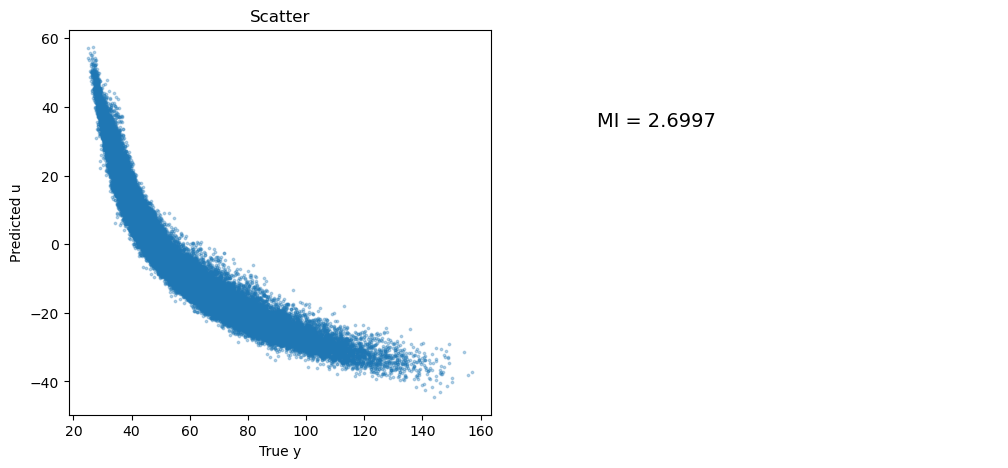

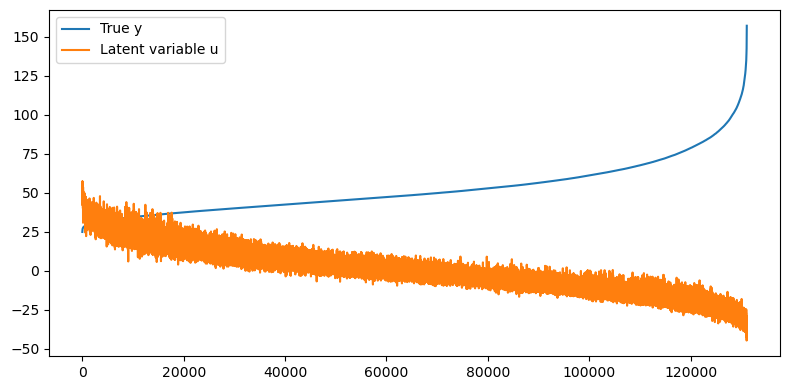

In [318]:
Theta_full = build_theta_from_model(
    X_val,
    sparse_result_lv_max,
    param_names,
)

#直接解析字符串的
# Theta_full = build_theta_from_feature_names(
#     X_val,
#     sparse_result_lv_max["library_feature_names"],
#     param_names,
# )

Theta_full_scaled = sparse_result_lv_max["scaler"].transform(
    Theta_full
)

Theta_scaled = Theta_full_scaled[
    :,
    sparse_result_lv_max["active_indices"]
]

u = visualize_sparse_prediction(
    Theta_scaled,
    y_lv_max_val,
    "sparse_result_lv_max.pkl",
)

#没保存原features的时候的
# Theta_augmented_v = build_theta_from_feature_names(
#     X_val,
#     sparse_result_lv_max["feature_names"],
#     param_names,
# )
# old_scaler = sparse_result_lv_max["scaler"]
# active = sparse_result_lv_max["active_indices"]

# new_scaler = StandardScaler()

# new_scaler.mean_ = old_scaler.mean_[active]
# new_scaler.scale_ = old_scaler.scale_[active]
# new_scaler.var_ = old_scaler.var_[active]
# new_scaler.n_features_in_ = len(active)
# new_scaler.n_samples_seen_ = old_scaler.n_samples_seen_

# Theta_scaled = new_scaler.transform(Theta_augmented_v)
# u = visualize_sparse_prediction(
#     Theta_scaled,
#     y_lv_max_v,
#     "sparse_result_lv_max.pkl"
# )

MI          : 1.847592


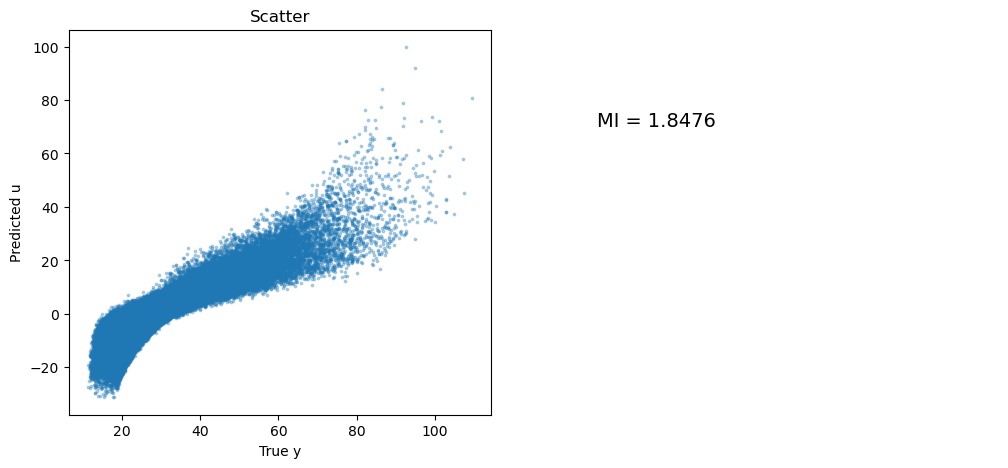

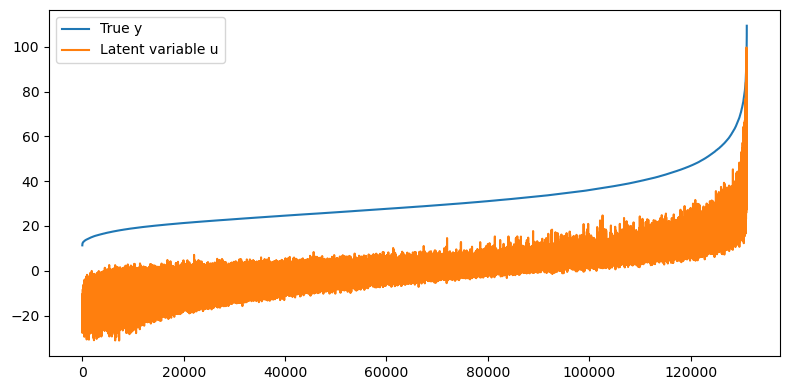

In [319]:
Theta_full_lv_min = build_theta_from_model(
    X_val,
    sparse_result_lv_min,
    param_names,
)

Theta_full_scaled_lv_min = sparse_result_lv_min["scaler"].transform(
    Theta_full_lv_min
)

Theta_scaled_lv_min = Theta_full_scaled_lv_min[
    :,
    sparse_result_lv_min["active_indices"]
]

u = visualize_sparse_prediction(
    Theta_scaled_lv_min,
    y_lv_min_val,
    "sparse_result_lv_min.pkl",
)

MI          : 2.965604


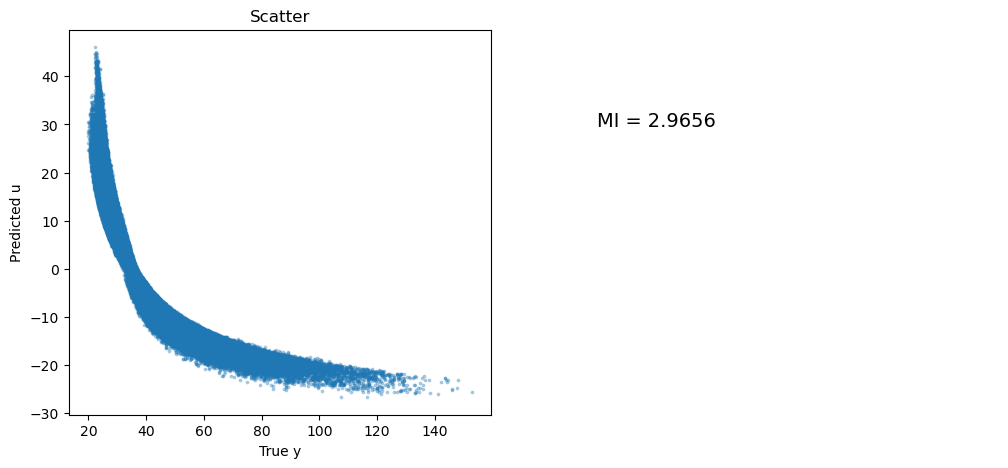

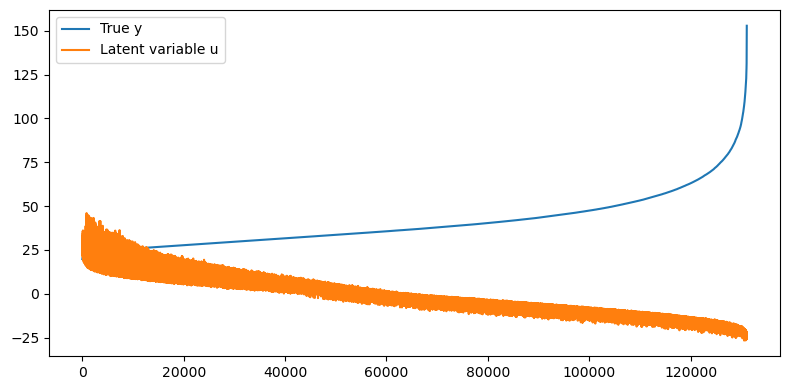

In [320]:
Theta_full_rv_max = build_theta_from_model(
    X_val,
    sparse_result_rv_max,
    param_names,
)

Theta_full_scaled_rv_max = sparse_result_rv_max["scaler"].transform(
    Theta_full_rv_max
)

Theta_scaled_rv_max = Theta_full_scaled_rv_max[
    :,
    sparse_result_rv_max["active_indices"]
]

u = visualize_sparse_prediction(
    Theta_scaled_rv_max,
    y_rv_max_val,
    "sparse_result_rv_max.pkl",
)

MI          : 2.450815


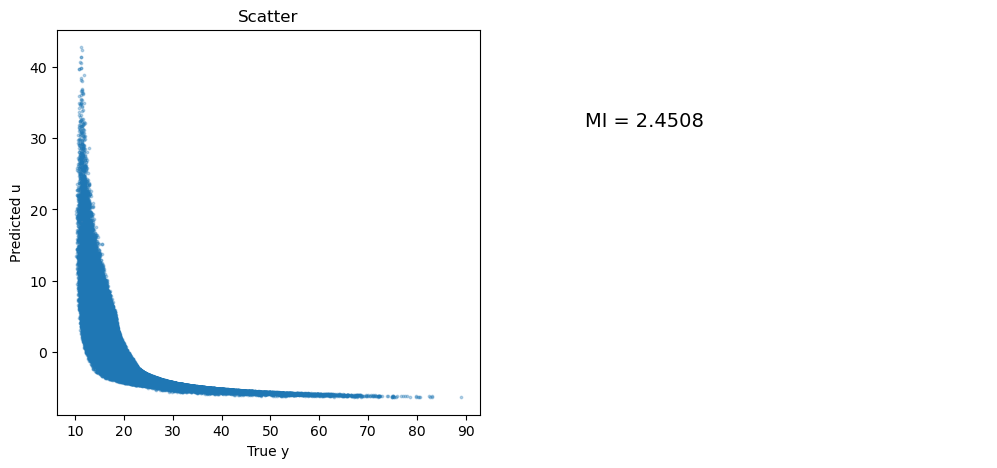

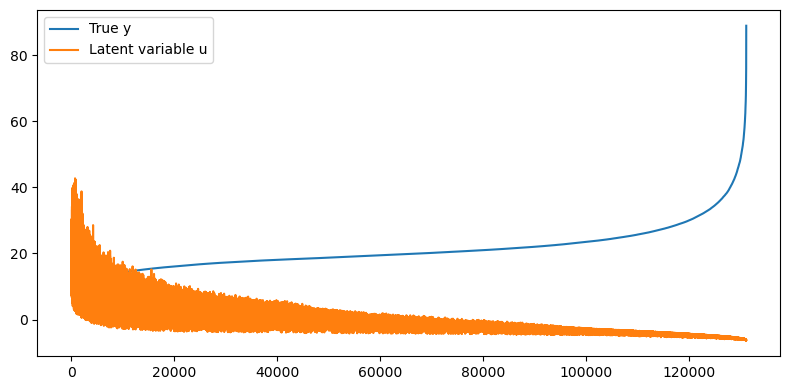

In [322]:
Theta_full_rv_min = build_theta_from_model(
    X_val,
    sparse_result_rv_min,
    param_names,
)

Theta_full_scaled_rv_min = sparse_result_rv_min["scaler"].transform(
    Theta_full_rv_min
)

Theta_scaled_rv_min = Theta_full_scaled_rv_min[
    :,
    sparse_result_rv_min["active_indices"]
]

u = visualize_sparse_prediction(
    Theta_scaled_rv_min,
    y_rv_min_val,
    "sparse_result_rv_min.pkl",
)

MI          : 3.147237


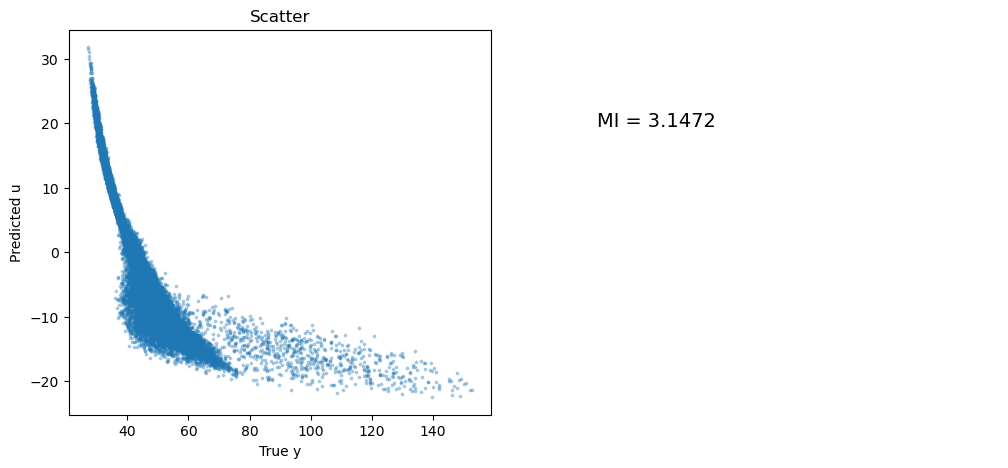

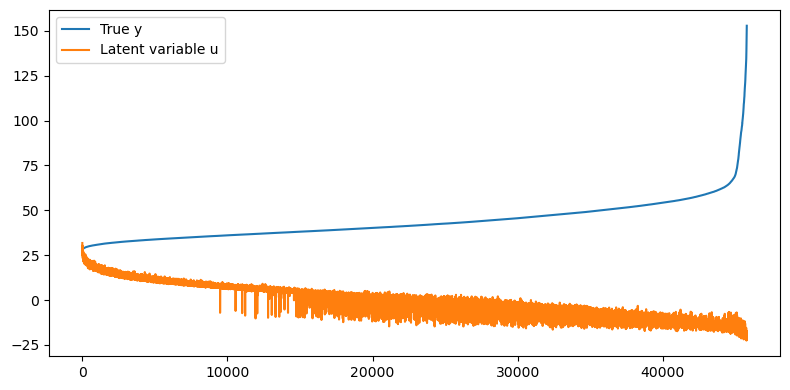

In [44]:
c_Theta_full_lv_max = build_theta_from_model(
    c_X_val,
    c_sparse_result_lv_max,
    param_names,
)

c_Theta_full_scaled_lv_max = c_sparse_result_lv_max["scaler"].transform(
    c_Theta_full_lv_max
)

c_Theta_scaled_lv_max = c_Theta_full_scaled_lv_max[
    :,
    c_sparse_result_lv_max["active_indices"]
]

u = visualize_sparse_prediction(
    c_Theta_scaled_lv_max,
    c_y_lv_max_val,
    "c_sparse_result_lv_max.pkl",
)

MI          : 3.269895


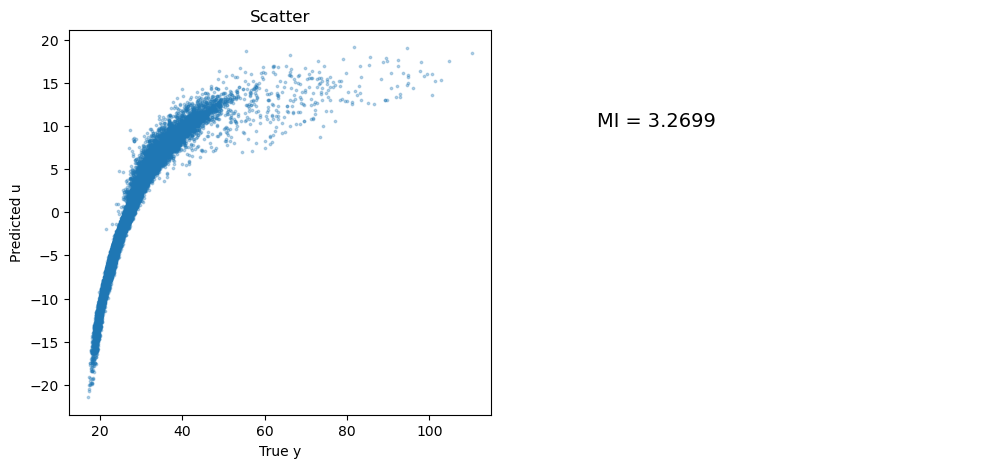

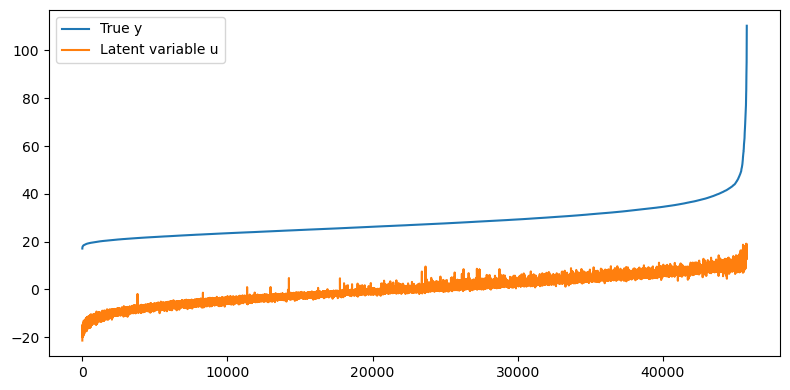

In [41]:
c_Theta_full_lv_min = build_theta_from_model(
    c_X_val,
    c_sparse_result_lv_min,
    param_names,
)

c_Theta_full_scaled_lv_min = c_sparse_result_lv_min["scaler"].transform(
    c_Theta_full_lv_min
)

c_Theta_scaled_lv_min = c_Theta_full_scaled_lv_min[
    :,
    c_sparse_result_lv_min["active_indices"]
]

u = visualize_sparse_prediction(
    c_Theta_scaled_lv_min,
    c_y_lv_min_val,
    "c_sparse_result_lv_min.pkl",
)

MI          : 1.851073


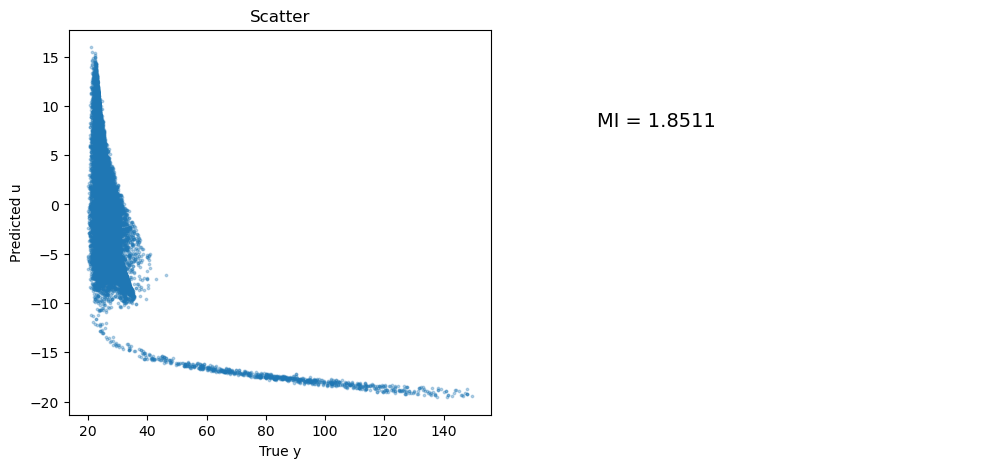

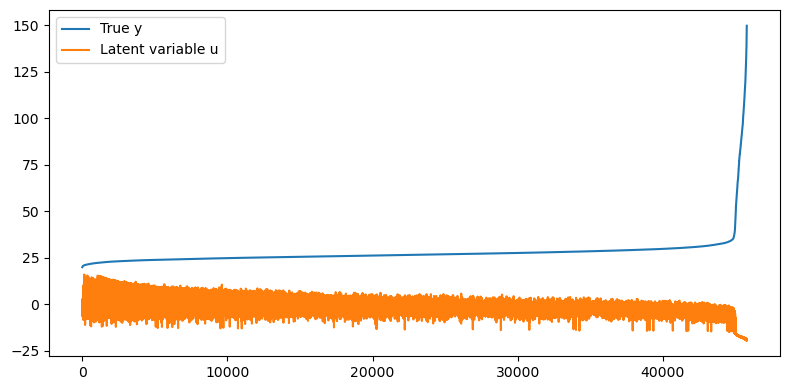

In [40]:
c_Theta_full_rv_max = build_theta_from_model(
    c_X_val,
    c_sparse_result_rv_max,
    param_names,
)

c_Theta_full_scaled_rv_max = c_sparse_result_rv_max["scaler"].transform(
    c_Theta_full_rv_max
)

c_Theta_scaled_rv_max = c_Theta_full_scaled_rv_max[
    :,
    c_sparse_result_rv_max["active_indices"]
]

u = visualize_sparse_prediction(
    c_Theta_scaled_rv_max,
    c_y_rv_max_val,
    "c_sparse_result_rv_max.pkl",
)

MI          : 2.232627


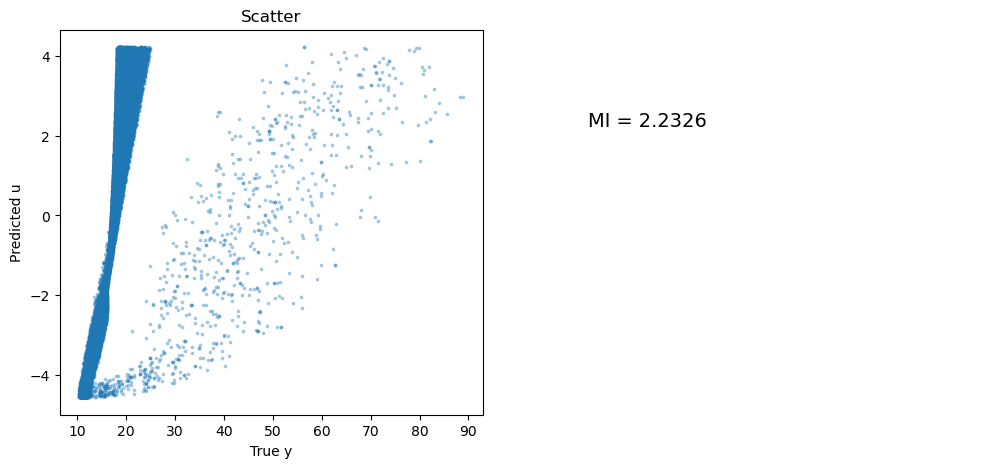

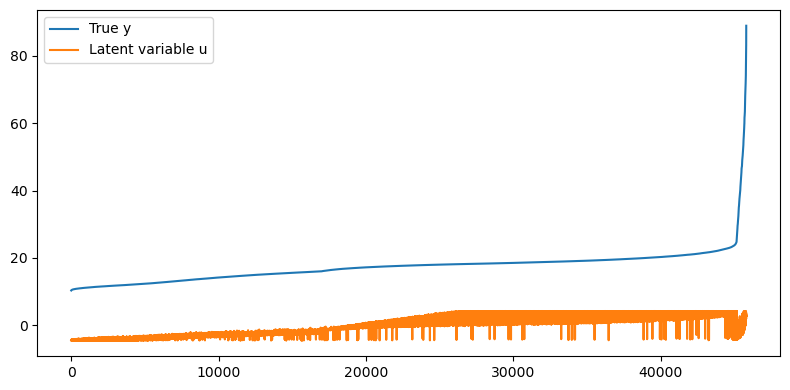

In [41]:
c_Theta_full_rv_min = build_theta_from_model(
    c_X_val,
    c_sparse_result_rv_min,
    param_names,
)

c_Theta_full_scaled_rv_min = c_sparse_result_rv_min["scaler"].transform(
    c_Theta_full_rv_min
)

c_Theta_scaled_rv_min = c_Theta_full_scaled_rv_min[
    :,
    c_sparse_result_rv_min["active_indices"]
]

u = visualize_sparse_prediction(
    c_Theta_scaled_rv_min,
    c_y_rv_min_val,
    "c_sparse_result_rv_min.pkl",
)

In [54]:
y_val = c_y_rv_min_val

cloud_mask = y_val > 25

cloud_val_positions = np.where(cloud_mask)[0]

cloud_indices = c_val_idx[cloud_val_positions]

print("Number of cloud VPs:", len(cloud_indices))
print("First 20 indices:", cloud_indices[:20])

Number of cloud VPs: 654
First 20 indices: [18340 61248 37946 78813 24944 21492 71261 50224 34841  8278 75340 17153
 21459 79062  7386 44142 41769 49929 65454 49026]


In [76]:
normal_mask = ~cloud_mask
normal_indices = c_val_idx[np.where(normal_mask)[0]]

rng = np.random.default_rng(42)

cloud_sample = rng.choice(cloud_indices, size=5, replace=False)
normal_sample = rng.choice(normal_indices, size=5, replace=False)

Text(0, 0.5, 'Pressure')

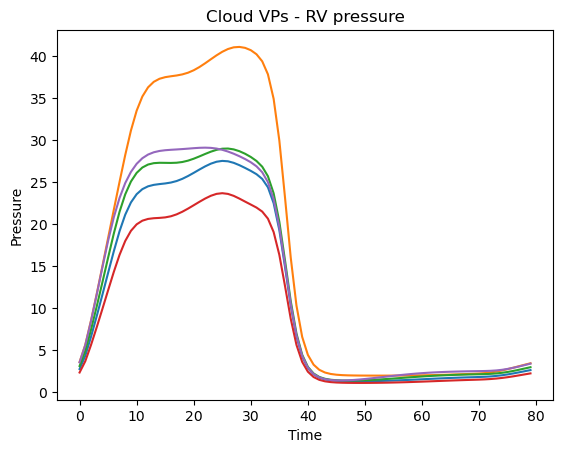

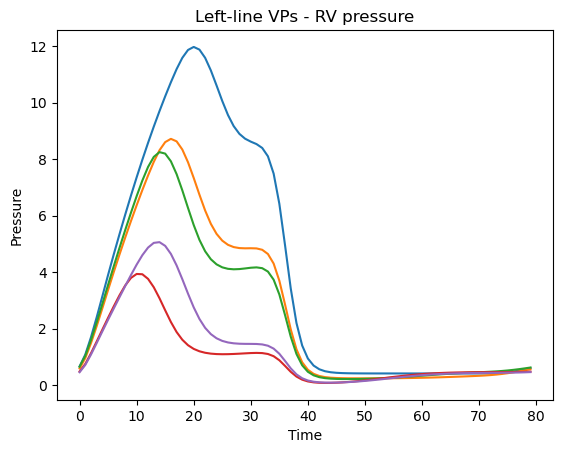

In [79]:
plt.figure()

for idx in cloud_sample:
    plt.plot(cleaned_data["p_rv"][idx])

plt.title("Cloud VPs - RV pressure")
plt.xlabel("Time")
plt.ylabel("Pressure")

plt.figure()

for idx in normal_sample:
    plt.plot(cleaned_data["p_rv"][idx])

plt.title("Left-line VPs - RV pressure")
plt.xlabel("Time")
plt.ylabel("Pressure")

In [96]:
def analyze_feature_cmi(
    sparse_result,
    Theta,
    y,
    print_result=True,
):

    coeff = sparse_result["coeff"]
    active_indices = sparse_result["active_indices"]
    feature_names = sparse_result["feature_names"]

    Theta_active = Theta[:, active_indices]

    results = []

    print("\n===== Conditional Mutual Information =====\n")

    for i in range(len(active_indices)):

        xi = Theta_active[:, i]

        other_idx = [j for j in range(len(active_indices)) if j != i]

        if len(other_idx) == 0:
            cmi = ee.mi(xi, y)
        else:
            z = Theta_active[:, other_idx]
            cmi = ee.cmi(xi, y, z)

        mi = ee.mi(xi, y)

        results.append({
            "feature": feature_names[i],
            "coefficient": coeff[i],
            "mi": mi,
            "cmi": cmi,
            "redundancy": mi - cmi
        })

    results = sorted(results, key=lambda r: r["cmi"], reverse=True)

    if print_result:

        print(
            f"{'Feature':45s}"
            f"{'Coeff':>10s}"
            f"{'MI':>12s}"
            f"{'CMI':>12s}"
            f"{'Redundant':>12s}"
        )

        for r in results:

            print(
                f"{r['feature'][:45]:45s}"
                f"{r['coefficient']:10.4f}"
                f"{r['mi']:12.4f}"
                f"{r['cmi']:12.4f}"
                f"{r['redundancy']:12.4f}"
            )

    return results

In [101]:
c_cmi_results_lv_max = analyze_feature_cmi(
    c_sparse_result_lv_max,
    c_Theta_augmented_scaled_lv_max,
    c_y_lv_max_train
)


===== Conditional Mutual Information =====

Feature                                           Coeff          MI         CMI   Redundant
C_p*R_p                                          2.1191      0.9654      0.0900      0.8753
R_p                                              2.5974      0.9413      0.0493      0.8920
C_s                                              2.4540      0.3220      0.0491      0.2730
C_s^0.556 * Za_s^-0.219 * R_s^-0.079 * C_p^0.    6.0325      2.5350      0.0409      2.4941
C_s^0.592 * Za_s^-0.257 * R_s^-0.123 * Za_p^-   -2.1297      1.5873      0.0316      1.5557
Za_p*R_p                                         0.0779      0.3772      0.0311      0.3461
C_s*C_p                                          0.1417      0.3983      0.0264      0.3719
C_s*R_s                                          0.1635      0.3096      0.0226      0.2870
Za_s                                            -1.5207      0.1683      0.0114      0.1569
Za_s*R_s                           

In [102]:
c_cmi_results_lv_min = analyze_feature_cmi(
    c_sparse_result_lv_min,
    c_Theta_augmented_scaled_lv_min,
    c_y_lv_min_train
)


===== Conditional Mutual Information =====

Feature                                           Coeff          MI         CMI   Redundant
C_s^0.839 * C_p^0.257 * R_p^0.480               -0.2531      1.3088      0.0585      1.2503
C_s                                             -1.9973      0.3911      0.0529      0.3382
C_s^0.814 * Za_s^-0.305 * C_p^0.246 * Za_p^-0   -2.3924      2.2324      0.0387      2.1937
C_s*C_p                                          0.6380      0.2860      0.0330      0.2530
C_p*R_p                                         -1.5455      0.6399      0.0307      0.6092
Za_s^-0.562 * R_s^-0.507 * C_p^0.227 * R_p^0.    0.1689      1.1754      0.0249      1.1505
Za_s^2                                           0.3917      0.2495      0.0247      0.2248
R_s*R_p                                          0.5990      0.5823      0.0235      0.5588
R_p                                             -2.1801      0.6251      0.0218      0.6033
R_p^2                              

In [100]:
c_cmi_results_rv_max = analyze_feature_cmi(
    c_sparse_result_rv_max,
    c_Theta_augmented_scaled_rv_max,
    c_y_rv_max_train
)


===== Conditional Mutual Information =====

Feature                                           Coeff          MI         CMI   Redundant
R_p                                             -0.3726      0.4040      1.2930     -0.8889
R_s                                              0.1682      0.3725      0.4726     -0.1000
C_s^2                                            0.1333      0.3282      0.4615     -0.1333
C_s^0.558 * Za_s^0.008 * R_s^0.681 * C_p^0.47    4.8980      1.8216      0.2975      1.5241
C_p^2                                            0.0678      0.2923      0.1517      0.1406


In [98]:
c_cmi_results_rv_min = analyze_feature_cmi(
    c_sparse_result_rv_min,
    c_Theta_augmented_scaled_rv_min,
    c_y_rv_min_train
)


===== Conditional Mutual Information =====

Feature                                           Coeff          MI         CMI   Redundant
R_p                                              2.8806      2.2147      3.4723     -1.2576
C_p^2                                            0.1207      0.7040      2.1320     -1.4280
C_s*R_s                                         -0.1745      0.3600      1.1395     -0.7794


In [51]:
def analyze_feature_importance(
    sparse_result,
    Theta,
    y,
    print_result=True,
):
    coeff = np.asarray(sparse_result["coeff"])
    active_indices = np.asarray(sparse_result["active_indices"])
    feature_names = sparse_result["feature_names"]

    Theta_active = Theta[:, active_indices]

    # full model
    u_full = Theta_active @ coeff
    full_mi = ee.mi(u_full, y)

    results = []

    for i in range(len(coeff)):

        keep = np.ones(len(coeff), dtype=bool)
        keep[i] = False

        # only one feature
        if keep.sum() == 0:
            mi_without = 0.0
            delta = full_mi

        else:

            u_without = Theta_active[:, keep] @ coeff[keep]

            mi_without = ee.mi(
                u_without,
                y
            )

            delta = full_mi - mi_without

        results.append({

            "feature": feature_names[i],

            "coefficient": coeff[i],

            "full_mi": full_mi,

            "mi_without": mi_without,

            "delta_mi": delta,

        })

    results.sort(
        key=lambda x: x["delta_mi"],
        reverse=True
    )

    if print_result:

        print("\n===== Feature Importance (Leave-One-Out MI) =====\n")

        print(
            f"{'Feature':45s}"
            f"{'Coeff':>10s}"
            f"{'ΔMI':>12s}"
            f"{'MI(-f)':>12s}"
        )

        print("-"*82)

        for r in results:

            print(
                f"{r['feature'][:45]:45s}"
                f"{r['coefficient']:10.4f}"
                f"{r['delta_mi']:12.4f}"
                f"{r['mi_without']:12.4f}"
            )

        print("-"*82)
        print(f"Full model MI : {full_mi:.6f}")

    return results

In [52]:
c_importance_lv_max = analyze_feature_importance(
    c_sparse_result_lv_max,
    c_Theta_augmented_scaled_lv_max,
    c_y_lv_max_train,
)


===== Feature Importance (Leave-One-Out MI) =====

Feature                                           Coeff         ΔMI      MI(-f)
----------------------------------------------------------------------------------
C_s^0.558 * Za_s^-0.227 * R_s^-0.076 * C_p^0.    9.5992      2.7840      0.3491
R_p                                              3.6220      1.2899      1.8432
Za_s                                            -2.3442      1.2841      1.8490
C_s                                              1.5568      0.9798      2.1534
C_p*R_p                                          2.5068      0.9766      2.1565
Za_p                                            -1.1895      0.7389      2.3942
C_p                                             -1.1792      0.6884      2.4447
Za_s*R_s                                         1.0811      0.5419      2.5912
C_s*R_p                                         -2.5286      0.4879      2.6452
R_s                                             -0.9704      0.45

In [107]:
c_importance_lv_min = analyze_feature_importance(
    c_sparse_result_lv_min,
    c_Theta_augmented_scaled_lv_min,
    c_y_lv_min_train,
)


===== Feature Importance (Leave-One-Out MI) =====

Feature                                           Coeff         ΔMI      MI(-f)
----------------------------------------------------------------------------------
Za_s                                             2.5830      1.8964      1.3810
C_s                                             -1.9973      1.7100      1.5674
R_p                                             -2.1801      1.4615      1.8159
R_s                                              1.2860      1.1462      2.1312
C_p*R_p                                         -1.5455      1.1201      2.1573
Za_s*R_s                                        -1.4258      0.9062      2.3712
Za_p                                             0.7769      0.7638      2.5136
C_s^0.814 * Za_s^-0.305 * C_p^0.246 * Za_p^-0   -2.3924      0.6720      2.6054
C_s*C_p                                          0.6380      0.4488      2.8286
R_s*R_p                                          0.5990      0.43

In [108]:
c_importance_rv_max = analyze_feature_importance(
    c_sparse_result_rv_max,
    c_Theta_augmented_scaled_rv_max,
    c_y_rv_max_train,
)


===== Feature Importance (Leave-One-Out MI) =====

Feature                                           Coeff         ΔMI      MI(-f)
----------------------------------------------------------------------------------
C_s^0.558 * Za_s^0.008 * R_s^0.681 * C_p^0.47    4.8980      1.1554      0.6936
R_s                                              0.1682      0.0630      1.7859
C_s^2                                            0.1333      0.0614      1.7876
C_p^2                                            0.0678     -0.0013      1.8503
R_p                                             -0.3726     -0.0103      1.8593
----------------------------------------------------------------------------------
Full model MI : 1.848989


In [109]:
c_importance_rv_min = analyze_feature_importance(
    c_sparse_result_rv_min,
    c_Theta_augmented_scaled_rv_min,
    c_y_rv_min_train,
)


===== Feature Importance (Leave-One-Out MI) =====

Feature                                           Coeff         ΔMI      MI(-f)
----------------------------------------------------------------------------------
R_p                                              2.8806      2.2293      0.2353
C_s*R_s                                         -0.1745      0.1648      2.2998
C_p^2                                            0.1207      0.0570      2.4076
----------------------------------------------------------------------------------
Full model MI : 2.464598


In [105]:
def analyze_feature_reoptimization(
    sparse_result,
    Theta,
    y,
    method="Powell",
    print_result=True,
):
    coeff = np.asarray(sparse_result["coeff"])
    active_indices = np.asarray(sparse_result["active_indices"])
    feature_names = np.asarray(sparse_result["feature_names"])

    Theta_active = Theta[:, active_indices]

    # --------------------------------------------------
    # Full model
    # --------------------------------------------------

    u_full = Theta_active @ coeff
    full_mi = ee.mi(u_full, y)

    results = []

    print("\n===== Leave-One-Out Re-optimization =====\n")
    print(f"Full model MI = {full_mi:.6f}\n")

    # --------------------------------------------------
    # Remove each feature
    # --------------------------------------------------

    for i in range(len(coeff)):

        removed_name = feature_names[i]

        keep = np.ones(len(coeff), dtype=bool)
        keep[i] = False

        Theta_reduced = Theta_active[:, keep]

        # Only one feature in original model
        if Theta_reduced.shape[1] == 0:

            reoptimized_mi = 0.0
            reoptimized_coeff = np.array([])

        else:

            # Use current coefficients as initial guess
            # rather than restarting from all ones
            x0 = coeff[keep].copy()

            result = minimize(
                scipy_objective,
                x0=x0,
                args=(Theta_reduced, y),
                method=method
            )

            # scipy_objective = -MI
            reoptimized_mi = -result.fun

            reoptimized_coeff = result.x.astype(float)

            # Normalize in the same way as sparse training
            norm = np.linalg.norm(reoptimized_coeff)

            if norm != 0:
                reoptimized_coeff /= norm

                z = Theta_reduced @ reoptimized_coeff

                if np.var(z) > 0:
                    gamma = (
                        np.cov(z, y, bias=True)[0, 1]
                        / np.var(z)
                    )

                    reoptimized_coeff *= gamma

                # Fix sign ambiguity
                idx = np.argmax(np.abs(reoptimized_coeff))

                if reoptimized_coeff[idx] < 0:
                    reoptimized_coeff *= -1

        # --------------------------------------------------
        # Information loss after allowing re-optimization
        # --------------------------------------------------

        delta_mi = full_mi - reoptimized_mi

        relative_loss = (
            delta_mi / full_mi
            if full_mi != 0
            else np.nan
        )

        results.append({
            "feature": removed_name,

            "coefficient": coeff[i],

            "full_mi": full_mi,

            "reoptimized_mi": reoptimized_mi,

            "delta_mi": delta_mi,

            "relative_loss": relative_loss,

            "remaining_features":
                feature_names[keep].tolist(),

            "reoptimized_coeff":
                reoptimized_coeff,
        })

        if print_result:

            print(
                f"Remove: {removed_name}\n"
                f"    MI after re-opt = {reoptimized_mi:.6f}\n"
                f"    ΔMI             = {delta_mi:.6f}\n"
                f"    Relative loss   = {relative_loss*100:.2f}%\n"
            )

    # Highest information loss first
    results.sort(
        key=lambda r: r["delta_mi"],
        reverse=True
    )

    if print_result:

        print("\n===== Summary =====\n")

        print(
            f"{'Removed Feature':45s}"
            f"{'MI(re-opt)':>12s}"
            f"{'ΔMI':>12s}"
            f"{'Loss %':>12s}"
        )

        print("-" * 81)

        for r in results:

            print(
                f"{r['feature'][:45]:45s}"
                f"{r['reoptimized_mi']:12.4f}"
                f"{r['delta_mi']:12.4f}"
                f"{r['relative_loss']*100:11.2f}%"
            )

    return results

In [106]:
c_reopt_lv_max = analyze_feature_reoptimization(
    c_sparse_result_lv_max,
    c_Theta_augmented_scaled_lv_max,
    c_y_lv_max_train,
)


===== Leave-One-Out Re-optimization =====

Full model MI = 3.147074

Remove: C_s
    MI after re-opt = 3.057964
    ΔMI             = 0.089110
    Relative loss   = 2.83%

Remove: Za_s
    MI after re-opt = 3.225143
    ΔMI             = -0.078069
    Relative loss   = -2.48%

Remove: R_s
    MI after re-opt = 3.222636
    ΔMI             = -0.075562
    Relative loss   = -2.40%

Remove: Za_p
    MI after re-opt = 3.271072
    ΔMI             = -0.123998
    Relative loss   = -3.94%

Remove: R_p
    MI after re-opt = 3.251054
    ΔMI             = -0.103981
    Relative loss   = -3.30%

Remove: C_p^2
    MI after re-opt = 3.344165
    ΔMI             = -0.197091
    Relative loss   = -6.26%

Remove: C_s*Za_s
    MI after re-opt = 3.101457
    ΔMI             = 0.045617
    Relative loss   = 1.45%

Remove: C_s*R_s
    MI after re-opt = 3.284049
    ΔMI             = -0.136975
    Relative loss   = -4.35%

Remove: C_s*C_p
    MI after re-opt = 3.215302
    ΔMI             = -0.068229
  

In [110]:
c_reopt_lv_min = analyze_feature_reoptimization(
    c_sparse_result_lv_min,
    c_Theta_augmented_scaled_lv_min,
    c_y_lv_min_train,
)


===== Leave-One-Out Re-optimization =====

Full model MI = 3.277384

Remove: C_s
    MI after re-opt = 3.144573
    ΔMI             = 0.132812
    Relative loss   = 4.05%

Remove: Za_s
    MI after re-opt = 3.371712
    ΔMI             = -0.094328
    Relative loss   = -2.88%

Remove: R_s
    MI after re-opt = 3.055393
    ΔMI             = 0.221991
    Relative loss   = 6.77%

Remove: Za_p
    MI after re-opt = 3.303653
    ΔMI             = -0.026268
    Relative loss   = -0.80%

Remove: R_p
    MI after re-opt = 3.191682
    ΔMI             = 0.085702
    Relative loss   = 2.61%

Remove: C_s^2
    MI after re-opt = 3.296832
    ΔMI             = -0.019448
    Relative loss   = -0.59%

Remove: Za_s^2
    MI after re-opt = 3.268144
    ΔMI             = 0.009240
    Relative loss   = 0.28%

Remove: R_p^2
    MI after re-opt = 3.228541
    ΔMI             = 0.048843
    Relative loss   = 1.49%

Remove: C_s*C_p
    MI after re-opt = 3.209850
    ΔMI             = 0.067534
    Relative 

In [111]:
c_reopt_rv_max = analyze_feature_reoptimization(
    c_sparse_result_rv_max,
    c_Theta_augmented_scaled_rv_max,
    c_y_rv_max_train,
)


===== Leave-One-Out Re-optimization =====

Full model MI = 1.848989

Remove: R_s
    MI after re-opt = 1.840317
    ΔMI             = 0.008671
    Relative loss   = 0.47%

Remove: R_p
    MI after re-opt = 1.825627
    ΔMI             = 0.023362
    Relative loss   = 1.26%

Remove: C_s^2
    MI after re-opt = 1.840252
    ΔMI             = 0.008737
    Relative loss   = 0.47%

Remove: C_p^2
    MI after re-opt = 1.828246
    ΔMI             = 0.020743
    Relative loss   = 1.12%

Remove: C_s^0.558 * Za_s^0.008 * R_s^0.681 * C_p^0.474 * Za_p^0.000 * R_p^-0.005
    MI after re-opt = 1.277249
    ΔMI             = 0.571739
    Relative loss   = 30.92%


===== Summary =====

Removed Feature                                MI(re-opt)         ΔMI      Loss %
---------------------------------------------------------------------------------
C_s^0.558 * Za_s^0.008 * R_s^0.681 * C_p^0.47      1.2772      0.5717      30.92%
R_p                                                1.8256      0.0234    

In [112]:
c_reopt_rv_min = analyze_feature_reoptimization(
    c_sparse_result_rv_min,
    c_Theta_augmented_scaled_rv_min,
    c_y_rv_min_train,
)


===== Leave-One-Out Re-optimization =====

Full model MI = 2.464609

Remove: R_p
    MI after re-opt = 0.949307
    ΔMI             = 1.515302
    Relative loss   = 61.48%

Remove: C_p^2
    MI after re-opt = 2.382199
    ΔMI             = 0.082410
    Relative loss   = 3.34%

Remove: C_s*R_s
    MI after re-opt = 2.268298
    ΔMI             = 0.196312
    Relative loss   = 7.97%


===== Summary =====

Removed Feature                                MI(re-opt)         ΔMI      Loss %
---------------------------------------------------------------------------------
R_p                                                0.9493      1.5153      61.48%
C_s*R_s                                            2.2683      0.1963       7.97%
C_p^2                                              2.3822      0.0824       3.34%


In [58]:
#test 修改objective function和先拟合power再加入function library的效果区别
#function能否同时拟合固定的参数？（原有25个，固定其他19个，在这里剩下6个变化的值）